In [1]:
from geostat_isoscapes_tools import utils, geostat_utils, plot_utils
import numpy as np
from scipy.stats import pearsonr

from pykrige.uk import UniversalKriging
import json
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import seaborn as snskl
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
sns.set_theme(context='talk',
                  style='ticks',
                  palette='colorblind',
                  rc={'axes.linewidth':1.2,"grid.alpha":0.3,"grid.linestyle":'--'})

#### KED computation for one time slice

The cell below is the workflow for our KED interpolation at one time slice. This automatized in script ```bin/kriging.py```.

> The workflow follows these steps :
> 1.  Define the parameters to use in the experiment (which variogram to use, path to the datasets...)
> 2.  Load SISAL (observations), iTraCE (external drift) and variogram data
> 3.  Compute the iTraCE field at SISAL observation points via a linear interpolation 
> 4.  Project all data (observation and external drift) in Mercator coordinate system, since kriging requires computing planar distances.
> 5.  Define the KED interpolator
> 6.  Interpolate
> 7.  Plot the resulting kriged maps and variance maps

In [2]:
###### SETUP ######
qty='d18Op_VSMOW_linearized'
res_months=200*12
# vario_path = f'{utils.get_project_root()}/output/variograms/itrace/sim12kyrBP/res2400/maxlag12000000nlags20/trend_multiple_linear_latabs_latReLU_ele_D/sisal_mask/variogram_params_None.json'
vario_path = '../output/variograms/2026-02-24_sisal_vs_itrace/itrace/sim12kyrBP/res2400/maxlag10000000nlags15/trend_multiple_linear_lat_latquad_ele_D/sisal_mask_2000km/variogram_params_None.json'
temperature_ds_name = 'itrace' # 1) 'itrace' for 20-11 ka BP, or 2) 'krapp' for 0-800ka BP with res 1000 years
temperature_ds_path = '/media/luluxette/T7_Shield/pdm/iTrace/'

itrace_folder = '/media/luluxette/T7_Shield/pdm/iTrace/' # abs path to itrace data 

###### LOAD DATA ######
# SISAL 
data_with_time_slices = geostat_utils.get_sisal_data_for_kriging(
    res=res_months//12,
    temp_ds_name=temperature_ds_name,
    temp_ds_path=temperature_ds_path,
    conversion=qty,
    verbose=False
)

# ITRACE 
itrace_data = geostat_utils.get_preprocessed_itrace_data(data_folder=itrace_folder,res=res_months,verbose=False) # simulation 12k
itrace_times = itrace_data['time'].unique() #type:ignore # thisis the bumber of time steps in itrace df
external_drift_df = itrace_data[itrace_data['time']==itrace_times[-1]].dropna() #type:ignore
external_drift_df['lon'] = utils.convert_lon_0_360_to_neg180_180(np.asarray(external_drift_df['lon'].values))
# plot_utils.plot_global_map(external_drift_df,'external drift','d18Op',unit='‰ VSMOW', lat_col='lat',lon_col='lon') # type:ignore
data_to_krige = data_with_time_slices[ (data_with_time_slices['binned_age']==11200)].copy()
# plot_utils.plot_global_map(data_to_krige,'sISAL data to krige - 11-11.2 kyr BP',unit='‰ VSMOW',quantity_col=qty,lat_col='lat',lon_col='lon') # type:ignore
###### VARIOGRAM ######
with open(vario_path, 'r') as f:
    variogram_dict = json.load(f)
# define variogram model
variogram_model = variogram_dict['model_name'] 
variogram_parameters = {
    "sill": variogram_dict['sill'], 
    "range": variogram_dict['range'],  
    "nugget": variogram_dict['nugget']
}
###### EXT DRIFT AT OBS POINTS ######
# Retrieve itrace **at** observation points
lats_obs = data_to_krige['lat']
lons_obs  = data_to_krige['lon']
# Linear interpolation from itrace grid to observation points
grid_points = np.column_stack((external_drift_df['lat'], external_drift_df['lon']))
obs_points = np.column_stack((lats_obs, lons_obs))
itrace_at_obs = griddata(grid_points, external_drift_df['d18Op'].values, obs_points, method='linear')
# fig,ax = plot_utils.plot_platecarree_field_and_scatter_on_top(external_drift_df,
#                                                               pd.DataFrame({'lat':lats_obs,'lon':lons_obs,'d18Op':itrace_at_obs}),
#                                                               )
# plt.show()
###### PROJECT IN MERCATOR COORDS ######
# Project data in CRS system for kriging 
data_to_krige['x'],data_to_krige['y'] = geostat_utils.project_coords(data_to_krige['lon'].values,data_to_krige['lat'].values)
external_drift_df['x'],external_drift_df['y'] = geostat_utils.project_coords(external_drift_df['lon'].values,external_drift_df['lat'].values)
itrace_values_xygrid = external_drift_df['d18Op'].values
###### KRIGING ######
# universal kriging object
uk = UniversalKriging(
    x=data_to_krige["x"],
    y=data_to_krige["y"],
    z=data_to_krige[qty],
    variogram_model=variogram_model,
    variogram_parameters=variogram_parameters,
    drift_terms=["specified"],
    specified_drift=[itrace_at_obs]
)
# execute 
z_pred, ss_pred = uk.execute(
    style="points",
    xpoints=external_drift_df['x'],
    ypoints=external_drift_df['y'],
    specified_drift_arrays=[itrace_values_xygrid]
)
# gather results in df
df_pred = pd.DataFrame({'lon': external_drift_df['lon'],
            'lat':external_drift_df['lat'],
            'z_pred':z_pred,
            'ss_pred':ss_pred})
# mask predictions according to a kriging variance threshold
df_pred_masked = df_pred[df_pred['ss_pred']<15]
###### PLOTTING ######
fig,axes = plot_utils.plot_ked_platecarree_points(
    df_pred=df_pred_masked,
    df_obs=data_to_krige,               
    value_col=qty,
    cmap='plasma',
    s_pred=80,
    figsize=(20,4),
    adjust_extent=False
) # type:ignore
plt.tight_layout()
# plt.savefig('../output/ked_firsttests/test_fig.png',dpi=500)
plt.show()

KeyboardInterrupt: 

#### Kriging validation metrics analysis 

In this section, we read and plot the cross-validation metrics obtained when running the script ```kriging.py```.

In [2]:
with open(f'{utils.get_project_root()}/data/iTrace_simulations_dict.json', 'r') as f:
    itrace_sims = json.load(f)
sims = dict((k,itrace_sims[k]) for k in ('12','13','14','15','16','17','18','19','20') if k in itrace_sims)
res = 200
list_crossval_df = []
list_crossval_metrics = [] 
for kyr in sims.keys():
    for time in range((int(kyr)-1)*1000+res,int(kyr)*1000+1,res):
        fp_output = f"{utils.get_project_root()}/output/kriging/runs_wip/2026-06-22/vario_n10/alpha5_percent/crop_lat_2/res{res}/plots_and_metrics/{str(int(time))}yrBP/" #run_2026_03_05_all_varios10
        crossval_df = pd.read_csv(f'{fp_output}crossval_df.csv').reset_index(drop=True)
        crossval_df['time']=time
        with open(fp_output+'crossval_metrics.json', 'r') as f: 
            crossval_metrics = json.load(f)
        list_crossval_df.append(crossval_df)
        list_crossval_metrics.append(pd.DataFrame(crossval_metrics,index=[time]))

crossval_df = pd.concat(list_crossval_df)
crossval_metrics = pd.concat(list_crossval_metrics)

In [3]:
df_list = []
for t in crossval_df.time.unique():
    r,_=pearsonr(crossval_df.loc[crossval_df.time==t,'z_pred'],crossval_df.loc[crossval_df.time==t,'residual'].values**2)
    df_list.append(pd.DataFrame({'t':[t],'R_pred_res2':[r]}))
df_r = pd.concat(df_list)
df_r = df_r.set_index('t',drop=True)
crossval_metrics['R_pred_res2'] = df_r.R_pred_res2
print(crossval_metrics.R_pred_res2.min())

-0.40475904056350664


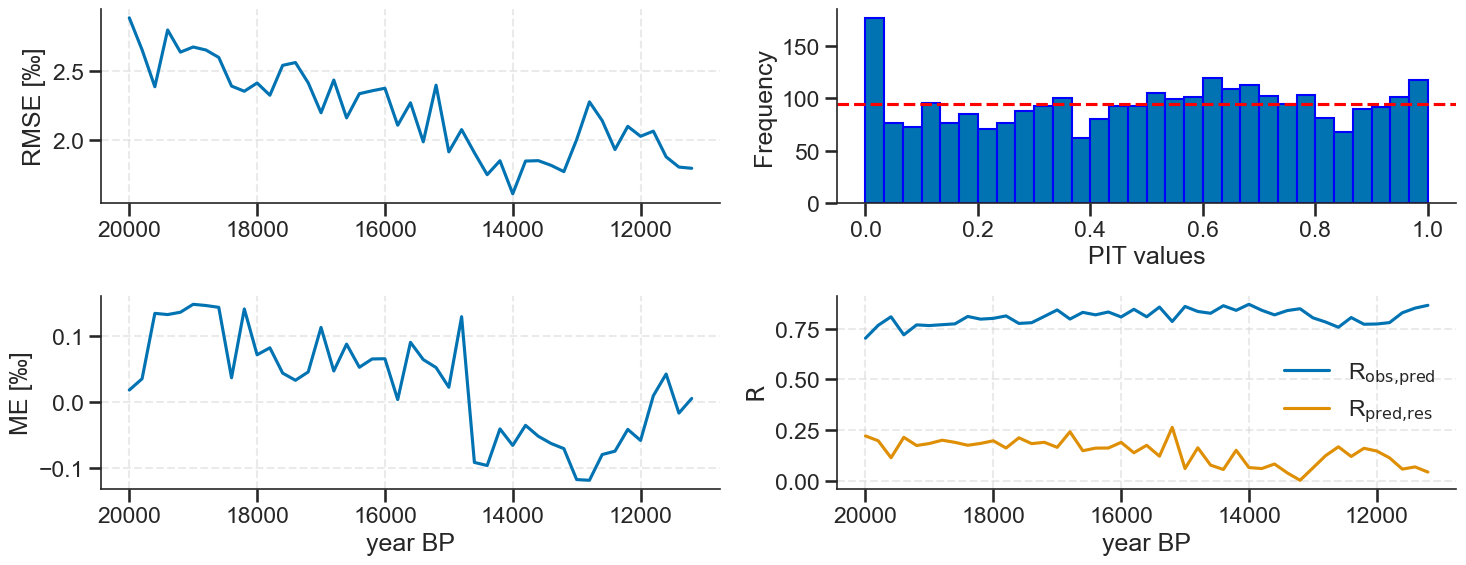

In [24]:
import scipy.stats as stats

# PIT = Phi((z_obs – z_pred) / sigma) with sigma = sqrt(variance)
sigma = np.sqrt(crossval_df['ss_pred'].values)
pit_vals = stats.norm.cdf((crossval_df['z_obs'].values-crossval_df['z_pred'].values)/sigma)
crossval_df['PIT'] = pit_vals
n=30


fig, axes = plt.subplots(2,2,figsize=(15,6))

# Scatter plot of irregular points
# axes[0].plot(crossval_metrics.index.values,crossval_metrics['MAE'])
axes[0,0].plot(crossval_metrics.index.values,crossval_metrics['RMSE'])
axes[0,0].set_ylabel('RMSE [‰]')
axes[1,0].plot(crossval_metrics.index.values,crossval_metrics['ME'])
axes[1,0].set_ylabel('ME [‰]')
axes[0,1].hist(pit_vals[~np.isnan(pit_vals)], bins=n, edgecolor='blue')  
axes[0,1].axhline(len(pit_vals)/n, color='red', linestyle='--')
axes[0,1].set_xlabel('PIT values')#axes[0,1].set_ylabel('mean CRPS [‰]')
axes[0,1].set_ylabel('Frequency')
axes[1,1].plot(crossval_metrics.index.values,crossval_metrics['R_obs_pred'],label=r'R$_\text{obs,pred}$')
axes[1,1].plot(crossval_metrics.index.values,crossval_metrics['R_pred_res'],label=r'R$_\text{pred,res}$')
# axes[1,1].plot(crossval_metrics.index.values,crossval_metrics['R_pred_res2'],label=r'R$_{\text{pred,res}^2}$')
axes[1,1].set_ylabel(r'$\text{R}$')
axes[1,1].legend(framealpha=0.0)
axes[1,1].set_xlabel('year BP')
axes[1,0].set_xlabel('year BP')
axes[0,0].grid(alpha=0.4)
axes[1,0].grid(alpha=0.4)
# axes[0,1].grid(alpha=0.4)
axes[1,1].grid(alpha=0.4)
sns.despine(top=True,right=True)
axes[1,0].invert_xaxis()
axes[0,0].invert_xaxis()
axes[1,1].invert_xaxis()
plt.tight_layout()
# plt.savefig('../output/essd_figs/fig_cvmetrics.png',dpi=300) #_noDevilsHole_noPacupahhuain
plt.show()

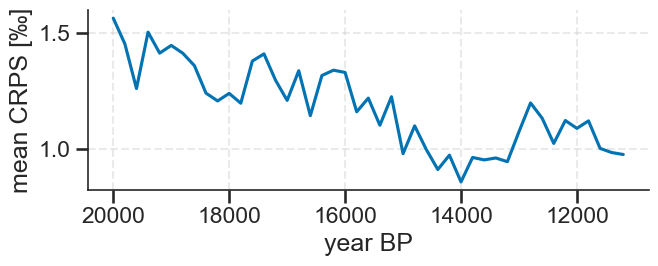

In [8]:
fig,ax = plt.subplots(figsize=(7,3))
ax.plot(crossval_metrics.index.values,crossval_metrics['mean CRPS'])
ax.set_xlabel('year BP')
ax.set_ylabel('mean CRPS [‰]')
ax.grid(alpha=0.4)
sns.despine(top=True,right=True)
plt.tight_layout()
ax.invert_xaxis()
# plt.savefig('../output/essd_figs/fig_crps.png',dpi=500) #_noDevilsHole_noPacupahhuain
plt.show()

In [9]:
crossval_metrics.RMSE.values[0]-crossval_metrics.RMSE.values[-1]

np.float64(-1.0908839493062945)

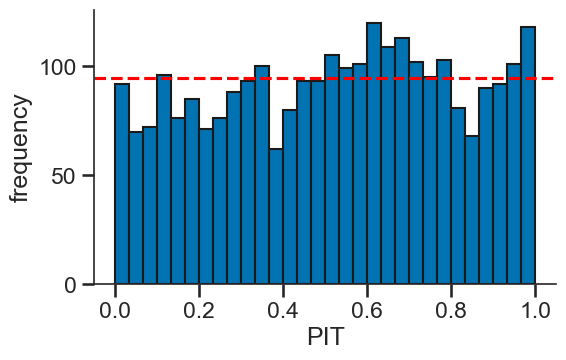

Skewness of PIT distribution: -0.09311576343760104


In [44]:
import scipy.stats as stats

# PIT = Phi((z_obs – z_pred) / sigma) with sigma = sqrt(variance)
sigma = np.sqrt(crossval_df['ss_pred'].values)
pit_vals = stats.norm.cdf((crossval_df['z_obs'].values-crossval_df['z_pred'].values)/sigma)
# obs - pred : underestimation>0, overestimation<0
crossval_df['PIT'] = pit_vals

#
n=30
plt.figure(figsize=(6,4))
plt.hist(crossval_df.loc[~crossval_df.site_name.isin(['Sofular cave','Pacupahuain cave','Sieben Hengste cave']),'PIT'].values, bins=n, edgecolor='k')
plt.axhline(len(pit_vals)/n, color='red', linestyle='--')
plt.xlabel('PIT')
plt.ylabel('frequency')
sns.despine()
plt.tight_layout()
# plt.savefig('../output/results_figs/PIT_histogram_agg_vario_noCriticalSites.png',dpi=500)
plt.show()

# compute skewness of PIT distribution
from scipy.stats import skew
skewness = skew(pit_vals[~np.isnan(pit_vals)])
print(f'Skewness of PIT distribution: {skewness}')
# we interpret a skewness value close to 0 as an indication of a well-calibrated model,
# while significant positive or negative skewness may suggest systematic biases in the predictions.
# In our case, a skewness of 0.26 suggests a slight bias towards underprediction (strong right tail),
# but it's not a strong deviation from 0, indicating that the model is reasonably well-calibrated.

In [11]:
crossval_df['err_drift'] = crossval_df.z_obs - crossval_df.drift_at_obs

In [45]:
df_pb = crossval_df[crossval_df.PIT<0.015]
df_pb.groupby('site_name').count().sort_values('lon')

,Unnamed: 0,lon,lat,z_pred,ss_pred,z_obs,drift_at_obs,ele (SISAL),ele (iTraCE),dist_nn,residual,PES,|PES| > critical_val,ci,time,PIT
site_name,,,,,,,,,,,,,,,,
Kalakot cave,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
Molinos cave,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
Mitoho,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4
Soreq cave,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4
Xiaobailong cave,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4
Chan Hol cave,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6
Nettlebed cave,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7
Seso cave,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7
Hölloch im Mahdtal,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8


In [13]:
(crossval_df.loc[crossval_df.site_name.isin(['Sofular cave']),'ele (SISAL)']-crossval_df.loc[crossval_df.site_name.isin(['Sofular cave']),'ele (iTraCE)']).mean()

np.float64(-159.21808743409252)

In [15]:
crossval_df.PIT.median()

0.5247872920825438

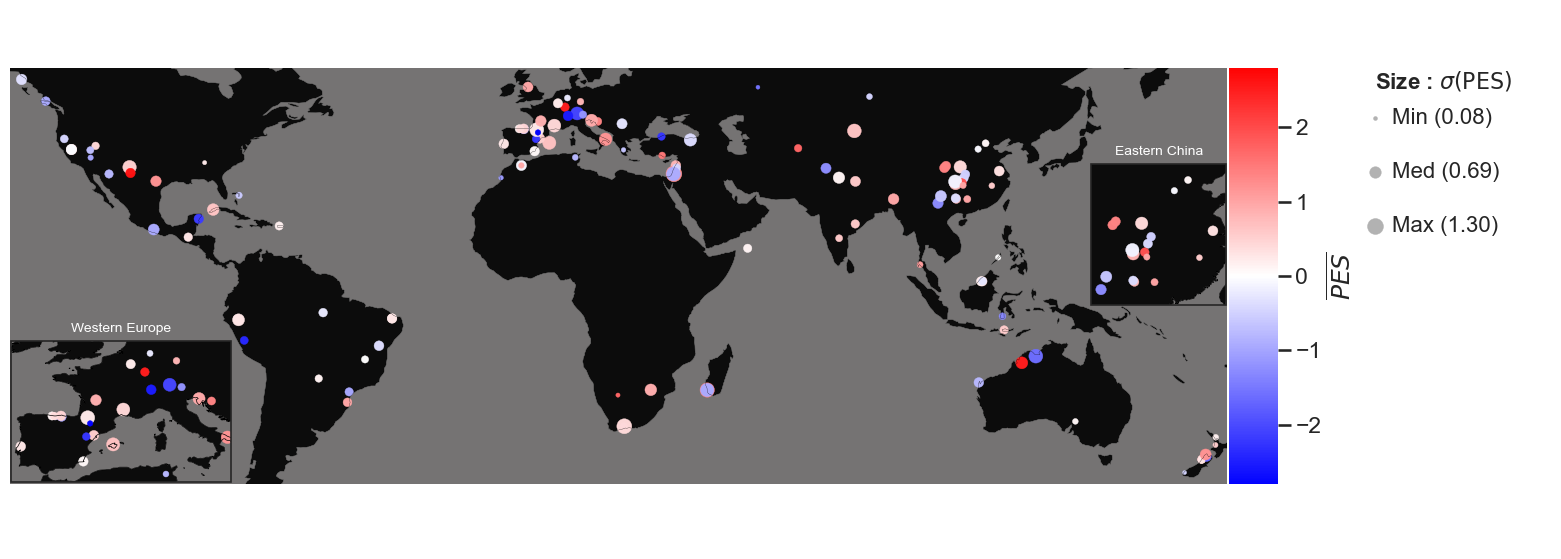

In [16]:
# map of metrics per site
def plot_metric_meanstd_per_site(crossval_df, qty_col,qty_label, cmap, cmap_sym0=False, unit='‰'):
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    from cartopy.mpl.geoaxes import GeoAxes
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    
    grp = crossval_df.groupby('site_name')
    df1 = pd.DataFrame({
        'lat': grp['lat'].first(),
        'lon': grp['lon'].first(),
        qty_col: grp[qty_col].mean(),
        f'{qty_col}_100std': (grp[qty_col].std()*100)
    }).reset_index()
    
    fig1,ax1= plot_utils.plot_latlon_platecarree_df(
        df=df1,
        figsize=(14,7),
        title=None,
        qty_col=qty_col,
        size_col=f'{qty_col}_100std',
        cmap=cmap,
        unit=unit,
        countries_borders=False,
        cmap_sym0=cmap_sym0,
        qty_label=rf'$\overline{{{qty_label}}}$',
        landcolor="#0C0C0C",
        oceancolor="#757373",
        marker='o',
        ) # type:ignore
    
    vmin = df1[qty_col].min() if not cmap_sym0 else min(df1[qty_col].min(),-df1[qty_col].max())
    vmax = df1[qty_col].max() if not cmap_sym0 else max(df1[qty_col].max(),-df1[qty_col].min())
    
    # Add insets for zoomed regions
    # Western Europe inset in Pacific Ocean
    axins_eu = inset_axes(ax1, width="34%", height="34%", loc='center left',
                         bbox_to_anchor=(-0.088, -0.325, 1, 1), bbox_transform=ax1.transAxes,
                         axes_class=GeoAxes, axes_kwargs=dict(projection=ccrs.PlateCarree()))
    axins_eu.set_extent([-10, 18, 35, 53], crs=ccrs.PlateCarree())
    
    # Plot data in Western Europe inset
    sc_eu = axins_eu.scatter(
        df1['lon'],
        df1['lat'],
        c=df1[qty_col],
        cmap=cmap,
        transform=ccrs.PlateCarree(),
        s=df1[f'{qty_col}_100std'],
        edgecolor=None,
        linewidths=0.3,
        alpha=0.99,
        vmin=vmin,
        vmax=vmax,
        marker='o'
    )
    axins_eu.add_feature(cfeature.COASTLINE, linewidth=0.5)
    axins_eu.add_feature(cfeature.LAND, facecolor="#0C0C0C", edgecolor="none")
    axins_eu.add_feature(cfeature.OCEAN, facecolor="#757373", edgecolor="none")
    axins_eu.set_title('Western Europe', fontsize=10,color='white')
    
    # Eastern China inset in Indian Ocean
    axins_china = inset_axes(ax1, width="34%", height="34%", loc='center right',
                            bbox_to_anchor=(0.123, 0.1, 1, 1), bbox_transform=ax1.transAxes,
                            axes_class=GeoAxes, axes_kwargs=dict(projection=ccrs.PlateCarree()))
    axins_china.set_extent([102, 121, 22, 42], crs=ccrs.PlateCarree())
    
    # Plot data in Eastern China inset
    sc_china = axins_china.scatter(
        df1['lon'],
        df1['lat'],
        c=df1[qty_col],
        cmap=cmap,
        transform=ccrs.PlateCarree(),
        s=df1[f'{qty_col}_100std'],
        edgecolor=None,
        linewidths=0.3,
        alpha=0.99,
        vmin=vmin,
        vmax=vmax,
        marker='o'
    )
    axins_china.add_feature(cfeature.COASTLINE, linewidth=0.5)
    axins_china.add_feature(cfeature.LAND, facecolor="#0C0C0C", edgecolor="none")
    axins_china.add_feature(cfeature.OCEAN, facecolor="#757373", edgecolor="none")
    axins_china.set_title('Eastern China', fontsize=10,color='white')
    
    return (fig1,ax1)

(fig1,ax1) = plot_metric_meanstd_per_site(crossval_df,'PES','PES','bwr',cmap_sym0=True,unit=None) # type:ignore
plt.tight_layout()
# plt.savefig('../output/essd_figs/fig_mapPES.png',dpi=300,bbox_inches='tight') 
plt.show()

In [14]:
crossval_df.columns

Index(['Unnamed: 0', 'site_name', 'lon', 'lat', 'z_pred', 'ss_pred', 'z_obs',
       'drift_at_obs', 'ele (SISAL)', 'ele (iTraCE)', 'dist_nn', 'residual',
       'PES', '|PES| > critical_val', 'ci', 'time', 'PIT', 'err_drift'],
      dtype='object')

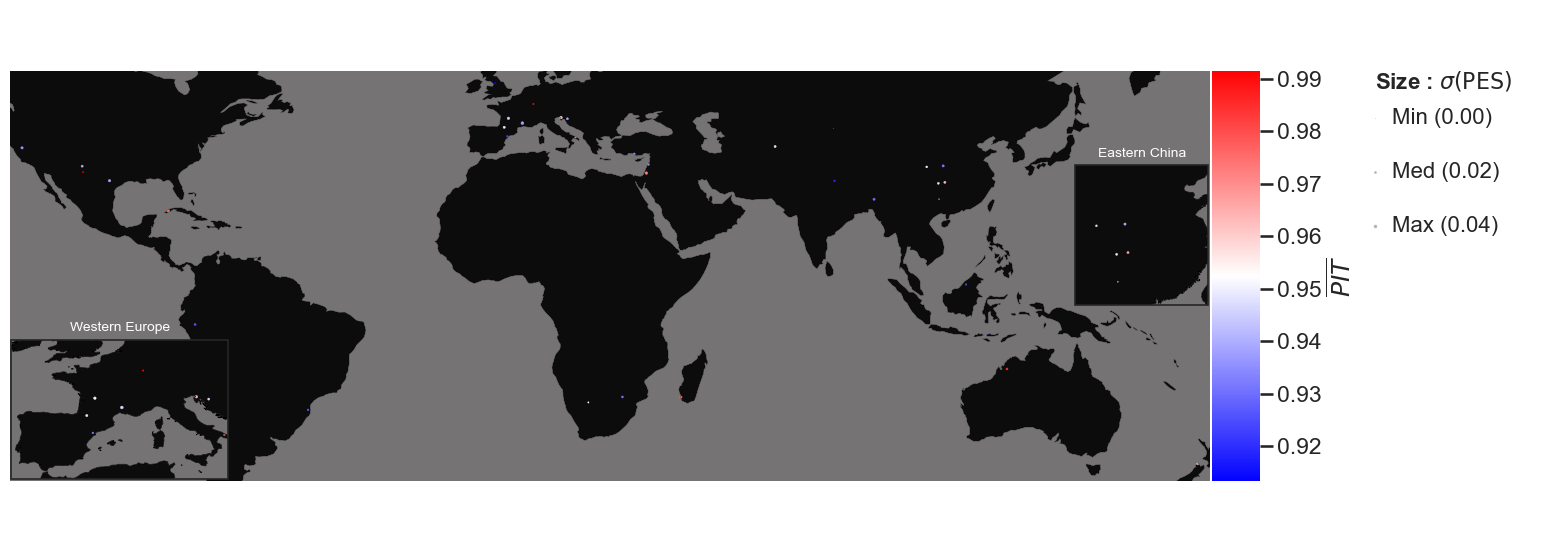

In [32]:
(fig1,ax1) = plot_metric_meanstd_per_site(crossval_df[crossval_df.PIT >0.9],'PIT','PIT','bwr',cmap_sym0=False,unit=None) # type:ignore
plt.tight_layout()
# plt.savefig('../output/essd_figs/fig_mapPES.png',dpi=300,bbox_inches='tight') 
plt.show()

Is the PES correlated to the altitude of the caves ? 

In [33]:
crossval_df.columns

Index(['Unnamed: 0', 'site_name', 'lon', 'lat', 'z_pred', 'ss_pred', 'z_obs',
       'drift_at_obs', 'ele (SISAL)', 'ele (iTraCE)', 'dist_nn', 'residual',
       'PES', '|PES| > critical_val', 'ci', 'time', 'PIT', 'err_drift'],
      dtype='object')

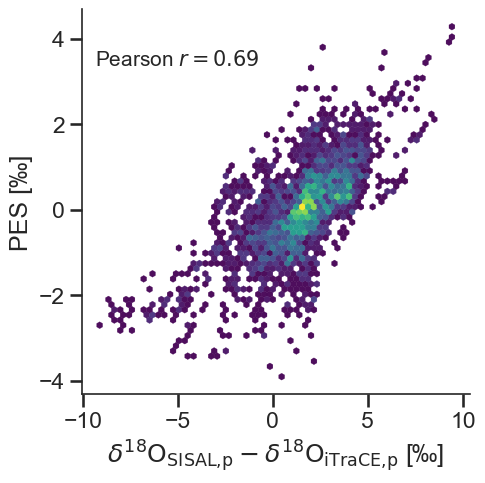

In [34]:
r, p_value = pearsonr(crossval_df['err_drift'],crossval_df['PES'])
fig,ax = plt.subplots(figsize=(5,5))
ax.hexbin(crossval_df['err_drift'],
    crossval_df['PES'],
    gridsize=60,
    cmap='viridis',
    mincnt=1,
    linewidths=0.2,
    alpha=0.95,)
ax.set_xlabel(r'$\delta^{18}\text{O}_\text{SISAL,p}-\delta^{18}\text{O}_\text{iTraCE,p}$ [‰]')
ax.set_ylabel('PES [‰]')
sns.despine()
fig.text(0.15, 0.8,
    fr'Pearson $r={r:.2f}$' '\n',
    va='top', ha='left', fontsize=15,
    bbox=dict(boxstyle='round', facecolor='white', edgecolor='none', alpha=0.9))
plt.savefig('../output/essd_figs/fig_PES_corr_drifterr.png',dpi=500)
plt.show()

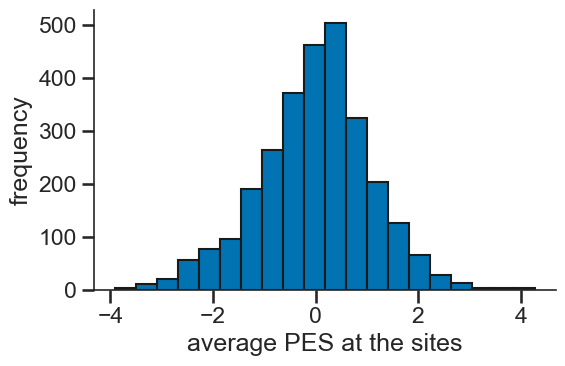

In [35]:
import scipy.stats as stats
# histogram of mean residuals per site 
plt.figure(figsize=(6,4))
plt.hist(crossval_df.PES.values, bins=20, edgecolor='k')
# plt.axhline(len(crossval_df.groupby('site_name')['PIT'].mean().values)/10, color='red', linestyle='--')
# overlay the normal distribution N(0,1)
# x = np.linspace(-3, 3, 100)
# y = stats.norm.pdf(x, loc=0, scale=0.6)
# plt.plot(x, y * len(crossval_df.groupby('site_name')) * 20 / 100, color='red', linewidth=2)
plt.xlabel('average PES at the sites')
plt.ylabel('frequency')
sns.despine()
plt.tight_layout() 
plt.show()

Let us observe the cross-val predictions at some caves versus the observed values, over the whole period.

In [17]:
def plot_pred_obs_at_site_over_time(crossval_df, site_name,fig=None,ax=None):
    df_site = crossval_df.loc[crossval_df.site_name == site_name].sort_values('time').copy()
    if fig is None or ax is None:
        fig, ax = plt.subplots(figsize=(7, 4))

    sigma = np.sqrt(np.clip(df_site['ss_pred'].values, 0, None))
    z_pred = df_site['z_pred'].values
    ci = 1.28 * sigma

    ax.fill_between(
        df_site.time.values,
        z_pred - ci,
        z_pred + ci,
        color='C0',
        edgecolor='none',
        alpha=0.15,
        label='80% CI',
    )
    ax.plot(df_site.time.values, z_pred, '--+', linewidth=1., markersize=6, label='CV prediction')
    ax.plot(df_site.time.values, df_site['z_obs'].values, '--.', linewidth=1., markersize=6, label='Observation')
    ax.plot(df_site.time.values, df_site['drift_at_obs'].values, '--x', linewidth=1., markersize=6, label='Drift value')

    ax.set_xlabel('Time [yr BP]')
    ax.set_ylabel(r'$\delta^{18}\text{O}$ [‰]')
    ax.set_title(site_name)
    ax.invert_xaxis()
    sns.despine()
    ax.legend(frameon=False, loc='center left', bbox_to_anchor=(1, 0.5))

    return fig, ax


---bad ones: 
- Ball Gown cave
- Sieben Hengste cave  

---good ones:
- cueva Victoria: bias (nn 700km)
- Haozhu cave: bias+pattern (nn 117km)
- Jaraguá cave: pattern (nn 800km)
- Lapa sem fim cave: pattern (nn 552 km)
- Liang Luar: bias (nn 800 km) (but there is a gap in the ts)
- Ruakuri cave: bias (200 km)

     site_name   lon    lat       PES
108  Seso cave  0.04  42.46 -2.803282


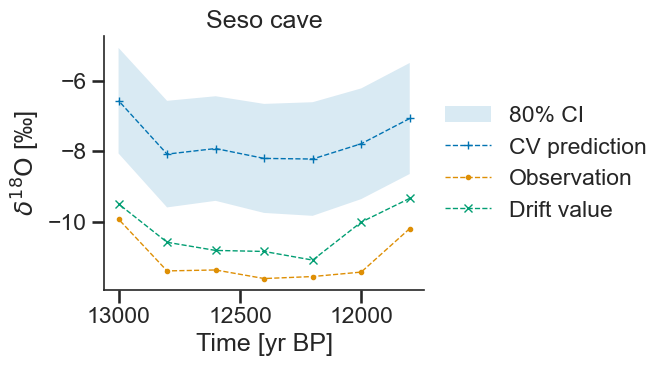

            site_name    lon   lat       PES
96  Pink Panther cave -105.2  32.0  2.584583


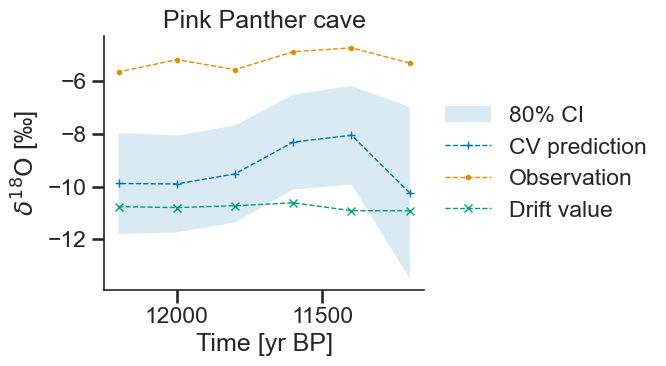

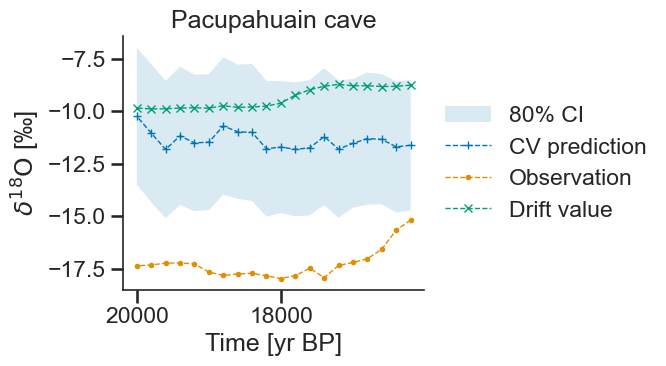

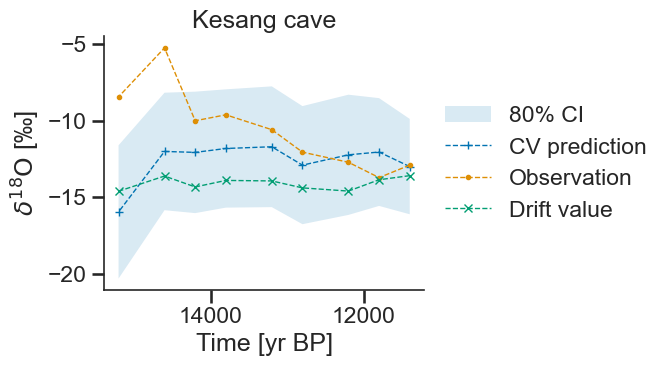

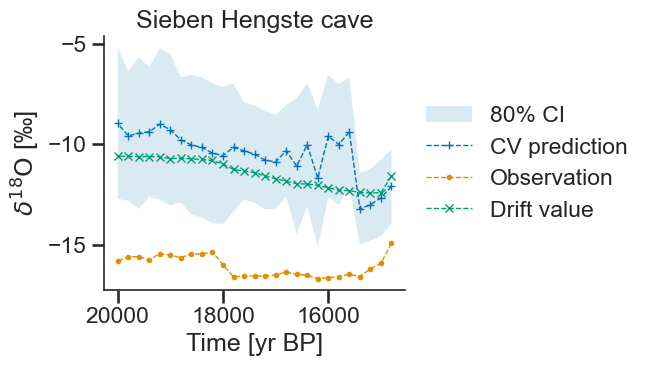

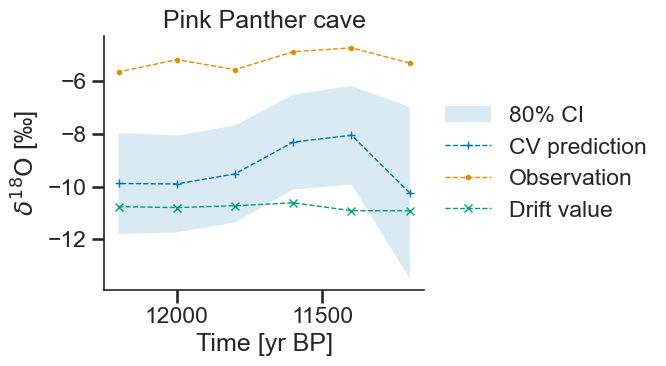

In [14]:
# explore the sites with the bad PES mean values :
mean_pes = crossval_df.groupby('site_name')[['lon','lat','PES']].mean().reset_index()
print(mean_pes[mean_pes.PES == mean_pes.PES.min()])
min_cave = mean_pes.loc[mean_pes.PES.idxmin(),'site_name']
fig,ax = plot_pred_obs_at_site_over_time(crossval_df,min_cave)
plt.tight_layout()
# plt.savefig('../output/results_figs/obs_pred_drift_DevilsHole.png',dpi=500)
plt.show()

#max
print(mean_pes[mean_pes.PES == mean_pes.PES.max()])
max_cave = mean_pes.loc[mean_pes.PES.idxmax(),'site_name']
fig,ax = plot_pred_obs_at_site_over_time(crossval_df,max_cave)
plt.tight_layout()
plt.show()

#Pacupahuain cave
fig, ax = plot_pred_obs_at_site_over_time(crossval_df,'Pacupahuain cave')
plt.tight_layout()
# plt.savefig('../output/results_figs/obs_pred_drift_Pacupahuain.png',dpi=500)
plt.show()

# Kesang cave 
fig,ax = plot_pred_obs_at_site_over_time(crossval_df,'Kesang cave')
plt.tight_layout()
# plt.savefig('../output/results_figs/obs_pred_drift_Kesang.png',dpi=500)
plt.show()

# Sieben Hengste cave
fig,ax = plot_pred_obs_at_site_over_time(crossval_df,'Sieben Hengste cave')
plt.tight_layout()
# plt.savefig('../output/results_figs/obs_pred_drift_SiebenHengste.png',dpi=500)
plt.show()

# Sieben Hengste cave
fig,ax = plot_pred_obs_at_site_over_time(crossval_df,'Pink Panther cave')
plt.tight_layout()
# plt.savefig('../output/results_figs/obs_pred_drift_PinkPantherCave.png',dpi=500)
plt.show()

##### Sites where the CV results are the best

summary : 
 - 4,51 "Bukit Assam cave", "Lianhua cave, Shanxi" : KED corrected the bias but the temporal patterns are still out of sync
 - 5 Buraca Gloriosa : Bias was greatly reduced but the iTraCE drift has smoothed temporal patterns, uncorrected.
 - 9,64,70,120 Creighton's cave, Palawan cave, Ruakuri cave, Mairs cave : bias greatly reduced -9 to -4 and -7.3 -5 and -8 to -5
 - 10,11,65,130 : Cueva Victoria, de Asiul, Pere Noel cave, Twin Forks cave : drift and obs were very correlated but bias was large : now largely corrected 
 - 12 : Bias in the other way (iTraCE overestimated d18O) greatly reduced + temporal pattern improvement
 - 16,22,63,83,93,100,114 : ?,Furong cave, Ostolo cave, Wazpretti cave, Hollywood cave, Pindal cave,Wet Neck cave : patterns match very well, bias midly reduced 
 - 20,35,37,48,58,123,126 : El Condor cave, KNI-51, Karaca cave, Leviathan cave, Moaning cave, cave C126, Pinnacle cave : strange behaviour in terms of temporal continuity !
 - 21,27,31,42,44,87 : El Soplao cave, Haozhu cave, Jaraguá cave, La Garma cave, La Vallina, Yamen cave : perfect CV result --> very close to another cave ?
 - 40,46,124 : Kulishu cave, Lapa sem fim cave, Larga cave : drift = obs - bias and less intense patterns --> all corrected, nice result (look at neighbourghs)?
 - Secret cave 75 : 8km to a neighbour...

In [15]:
crossval_df.loc[crossval_df.site_name.isin([
    'El Soplao cave', 
    'Haozhu cave', 
    'Jaraguá cave',
    'La Garma cave', 
    'La Vallina', 
    'Yamen cave',
    'Kulishu cave', 
    'Lapa sem fim cave', 
    'Larga cave'
    ]),['site_name','dist_nn']].groupby('site_name').min()

,dist_nn
site_name,
El Soplao cave,15.958929
Haozhu cave,117.461764
Jaraguá cave,891.629786
Kulishu cave,237.235562
La Garma cave,13.739668
La Vallina,22.380770
Lapa sem fim cave,552.591183
Larga cave,1380.880978
Yamen cave,28.873176


Haozhu cave


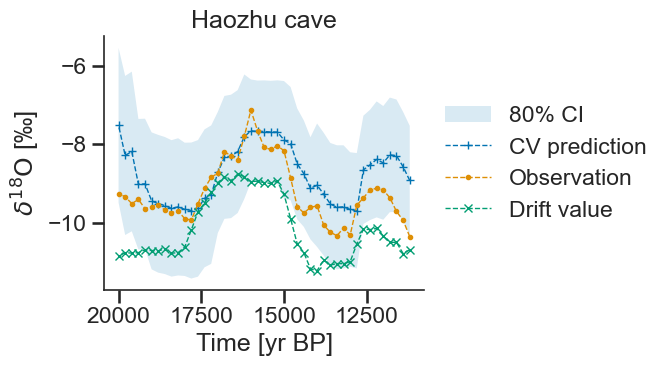

Kulishu cave


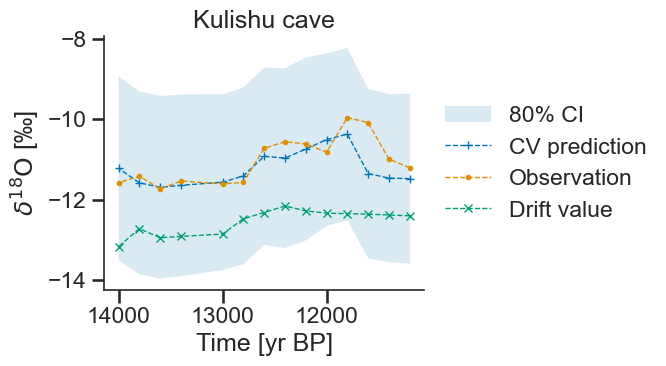

Lapa sem fim cave


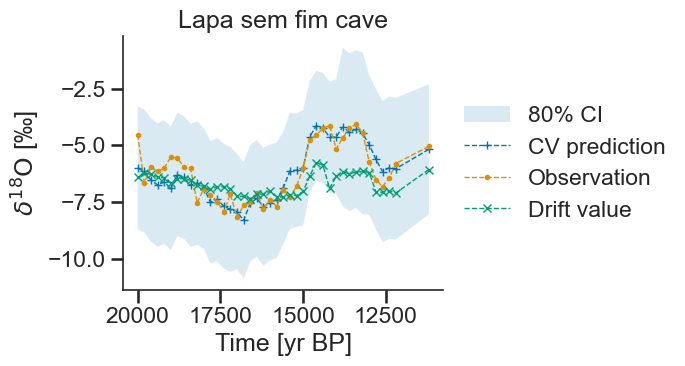

Jaraguá cave


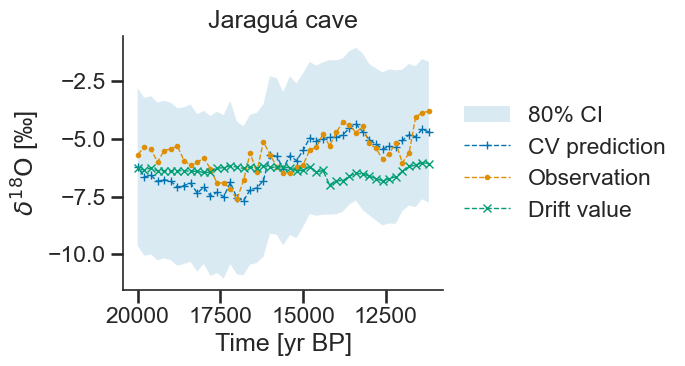

Larga cave


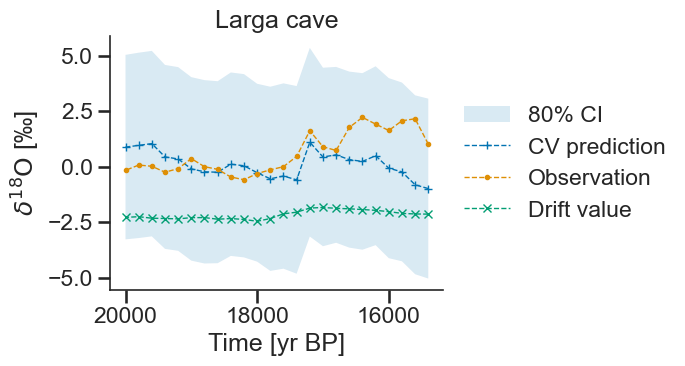

In [16]:
num = 26
print(crossval_df.site_name.unique()[num])
fig,ax = plot_pred_obs_at_site_over_time(crossval_df,crossval_df.site_name.unique()[num]) 
plt.tight_layout()
# plt.savefig('../output/results_figs/obs_pred_drift_PinkPantherCave.png',dpi=500)
plt.show()

num = 39
print(crossval_df.site_name.unique()[num])
fig,ax = plot_pred_obs_at_site_over_time(crossval_df,crossval_df.site_name.unique()[num]) 
plt.tight_layout()
# plt.savefig('../output/results_figs/obs_pred_drift_PinkPantherCave.png',dpi=500)
plt.show()

num = 45
print(crossval_df.site_name.unique()[num])
fig,ax = plot_pred_obs_at_site_over_time(crossval_df,crossval_df.site_name.unique()[num]) 
plt.tight_layout()
# plt.savefig('../output/results_figs/obs_pred_drift_PinkPantherCave.png',dpi=500)
plt.show()

num =30
print(crossval_df.site_name.unique()[num])
fig,ax = plot_pred_obs_at_site_over_time(crossval_df,crossval_df.site_name.unique()[num]) 
plt.tight_layout()
# plt.savefig('../output/results_figs/obs_pred_drift_PinkPantherCave.png',dpi=500)
plt.show()

num = 123
print(crossval_df.site_name.unique()[num])
fig,ax = plot_pred_obs_at_site_over_time(crossval_df,crossval_df.site_name.unique()[num]) 
plt.tight_layout()
# plt.savefig('../output/results_figs/obs_pred_drift_PinkPantherCave.png',dpi=500)
plt.show()

Arch cave nearest neighbourgh distance: 748.6036172344031


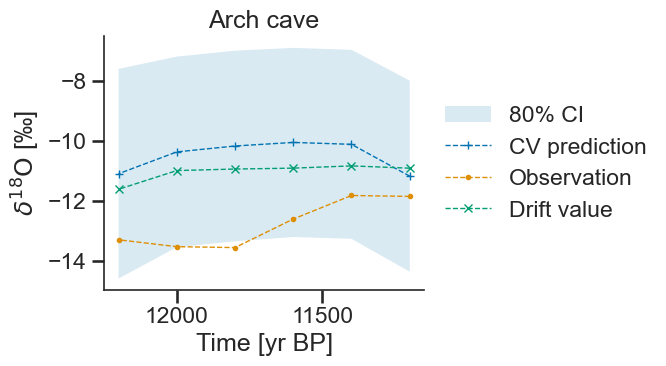

Ball Gown cave nearest neighbourgh distance: 431.8048314824116


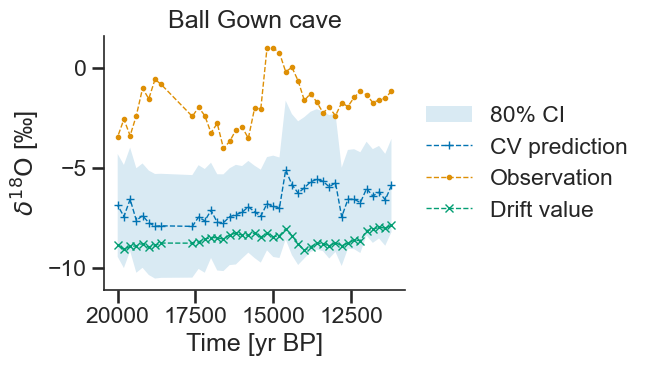

Botuverá cave nearest neighbourgh distance: 302.6232291967474


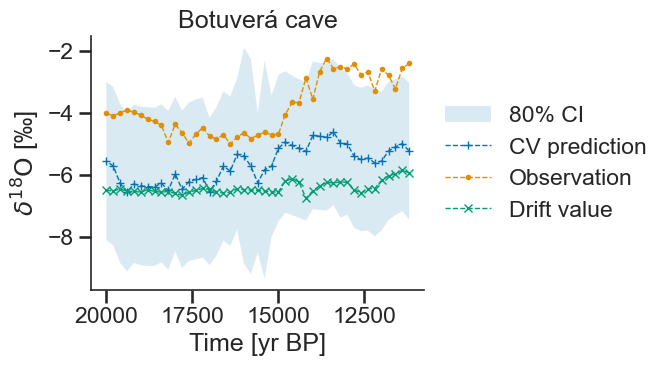

Bukit Assam cave nearest neighbourgh distance: 8.261762994230782


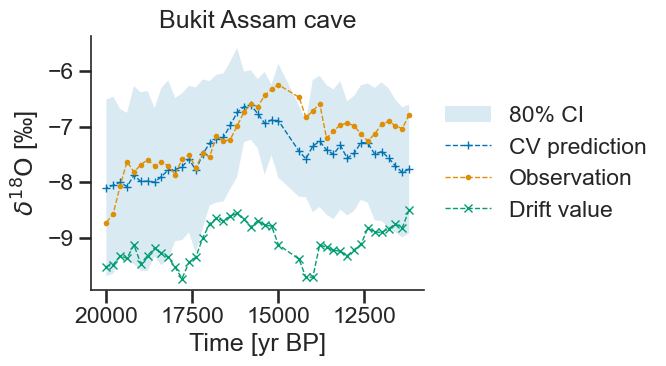

Buraca Gloriosa nearest neighbourgh distance: 543.5365932927459


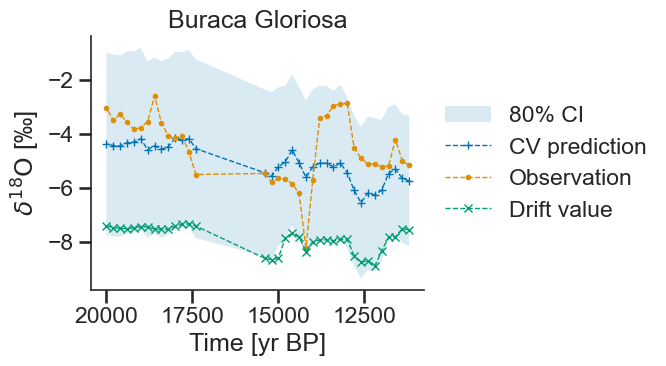

Chan Hol cave nearest neighbourgh distance: 3.840649999727035


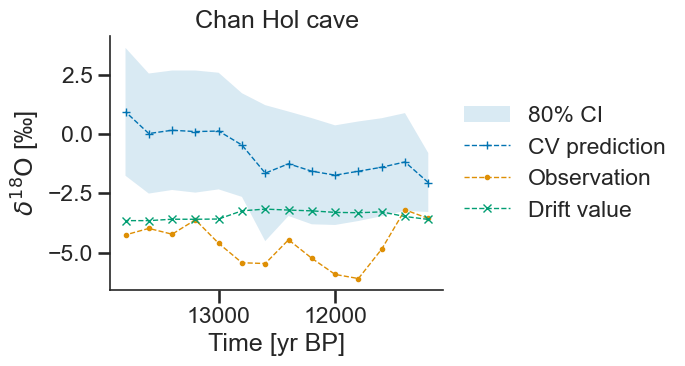

Creighton`s cave nearest neighbourgh distance: 7.829210336810948


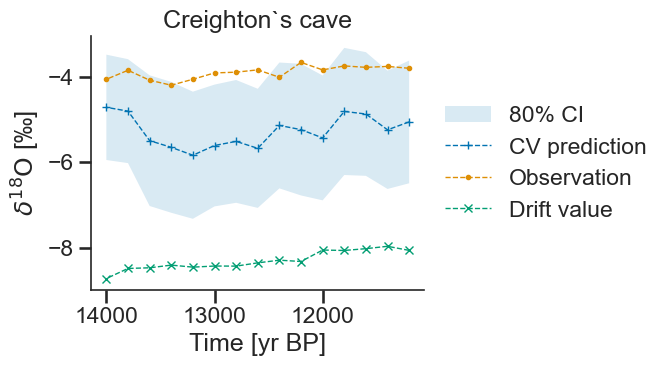

Cueva Victoria nearest neighbourgh distance: 352.86904582937296


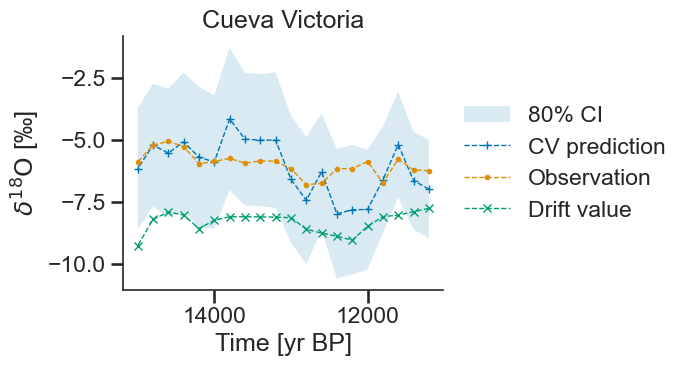

Cueva de Asiul nearest neighbourgh distance: 13.739668483176375


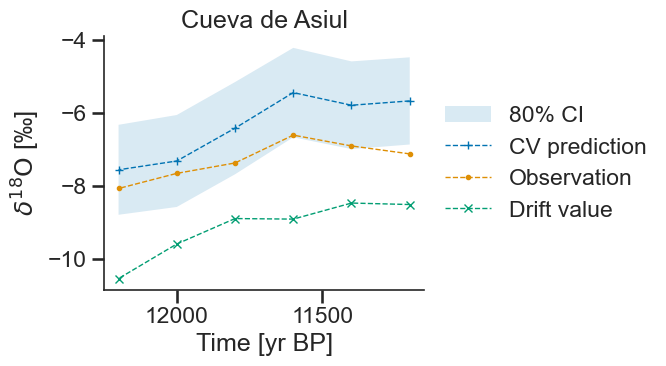

Cueva del Diamante nearest neighbourgh distance: 31.369435063083294


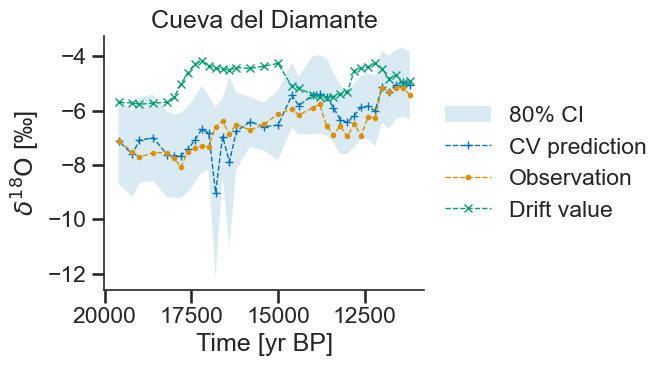

Cueva del Tigre Perdido nearest neighbourgh distance: 1.4804737149354987


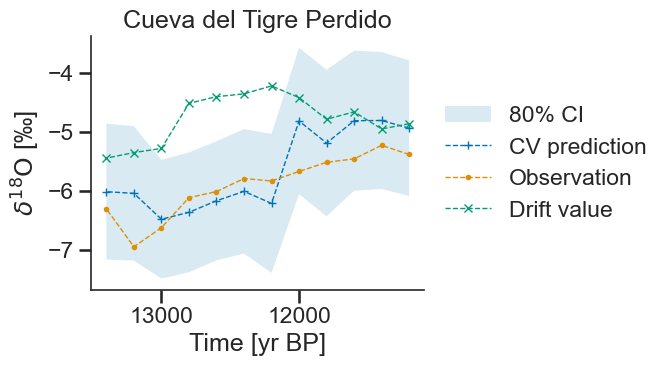

Dim cave nearest neighbourgh distance: 431.4080407110296


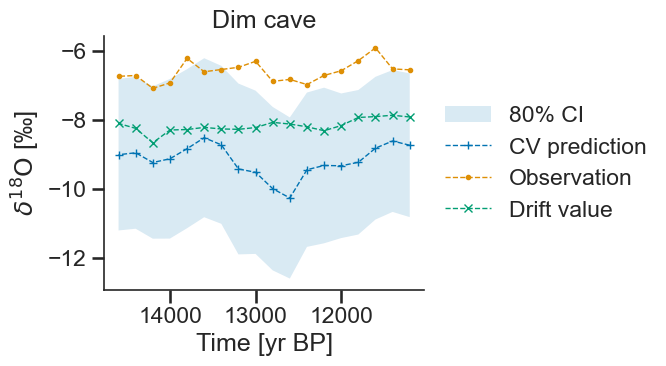

Dongge cave nearest neighbourgh distance: 28.87317596313951


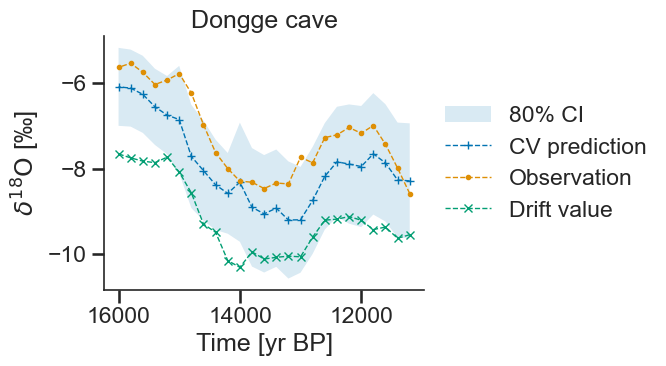

Dos Anas cave nearest neighbourgh distance: 443.4398978901406


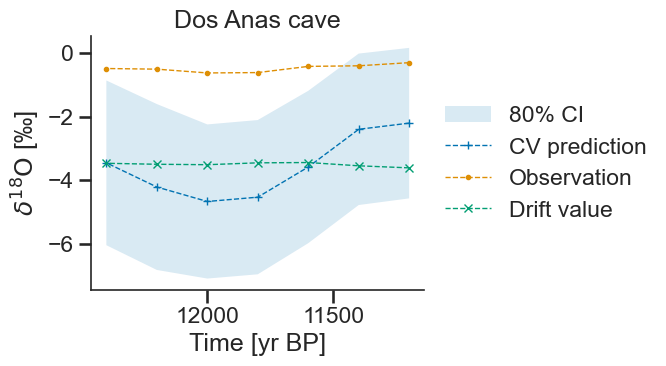

El Capitan cave nearest neighbourgh distance: 748.6036172344031


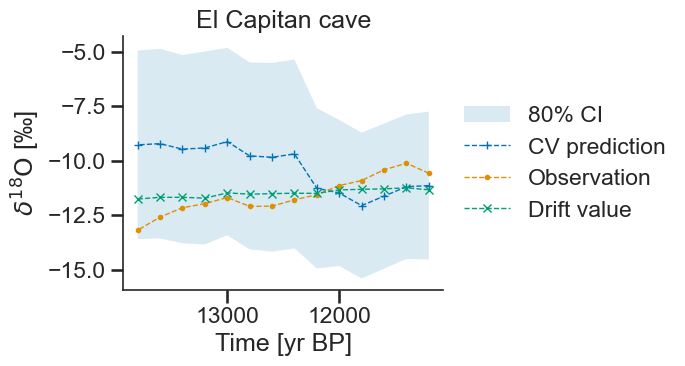

El Condor cave nearest neighbourgh distance: 1.4804737149354987


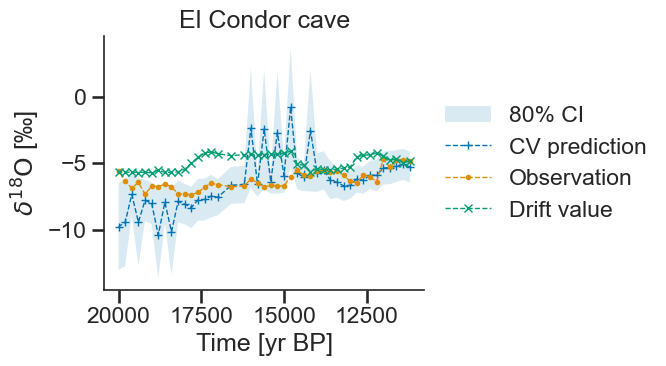

El Soplao cave nearest neighbourgh distance: 15.958928653096004


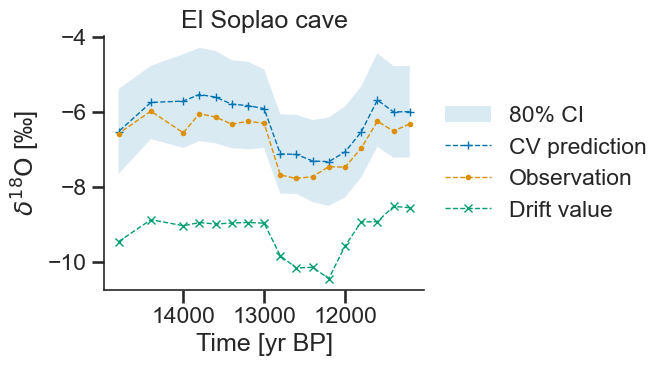

Furong cave nearest neighbourgh distance: 62.70871141155851


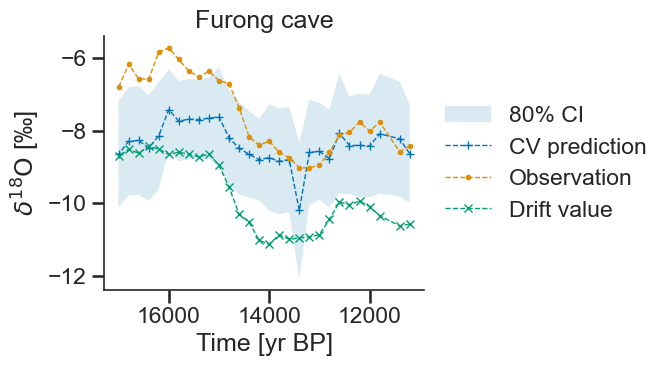

Gempa bumi cave nearest neighbourgh distance: 395.3784849177932


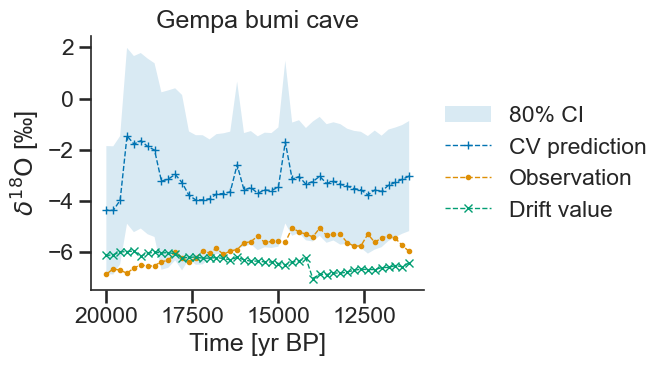

Gunung-buda cave (snail shell cave) nearest neighbourgh distance: 35.512025867917906


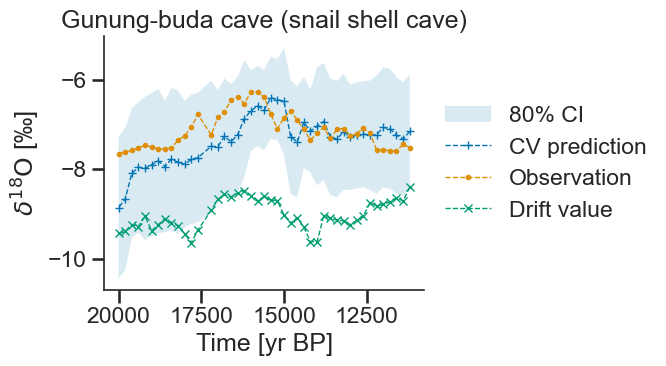

Haozhu cave nearest neighbourgh distance: 117.46176400876612


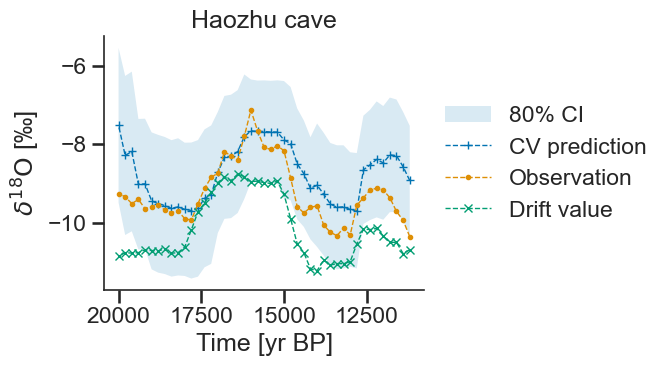

Hulu cave nearest neighbourgh distance: 459.3377314185644


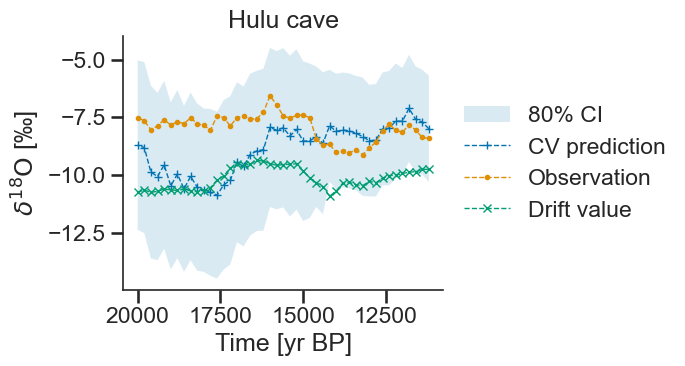

Hölloch im Mahdtal nearest neighbourgh distance: 119.4186139215746


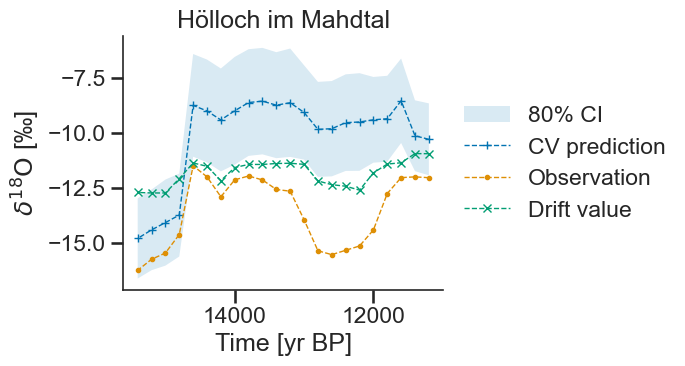

Jaraguá cave nearest neighbourgh distance: 891.6297858599761


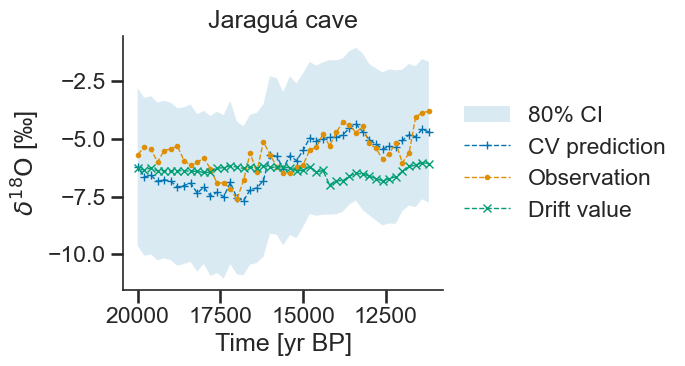

Jeita cave nearest neighbourgh distance: 71.6017072338472


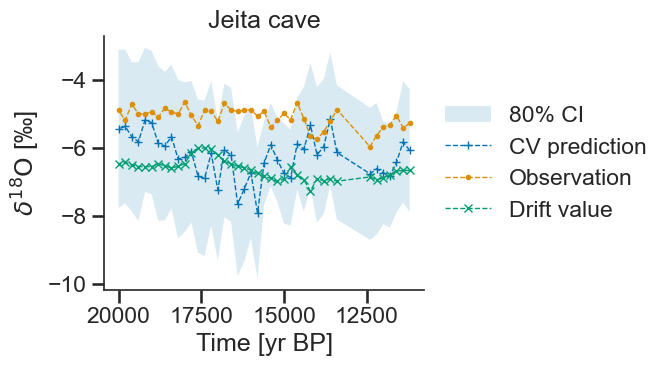

Jerusalem west cave nearest neighbourgh distance: 12.42587055291598


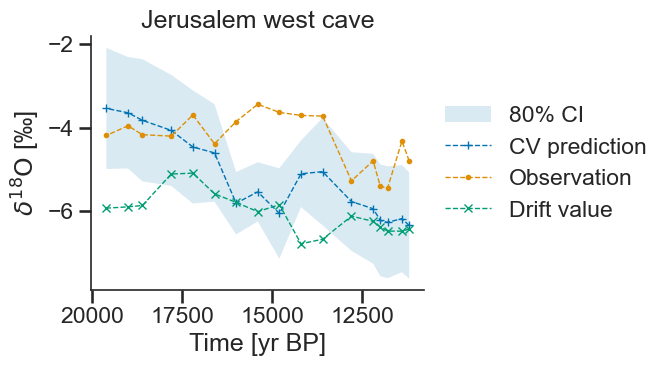

Jiuxian cave nearest neighbourgh distance: 245.38036021621247


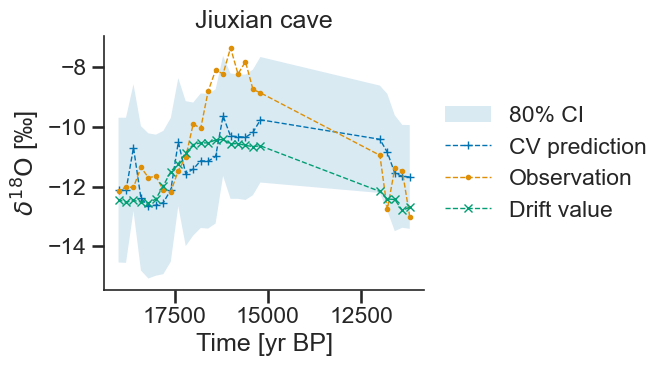

KNI-51 nearest neighbourgh distance: 431.8048314824116


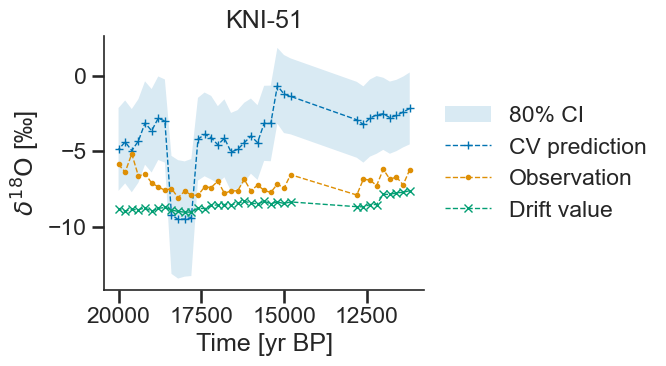

Kalakot cave nearest neighbourgh distance: 415.7898920057784


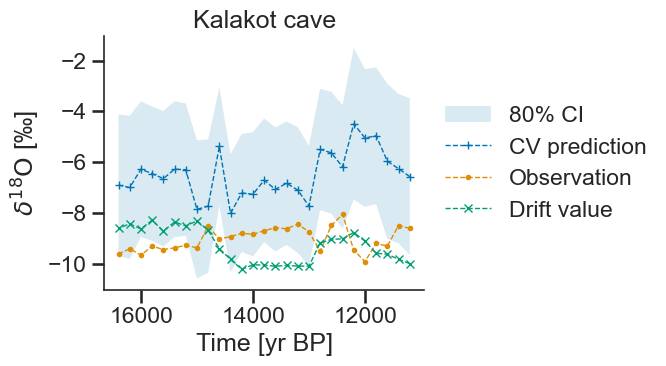

Karaca cave nearest neighbourgh distance: 634.2843089556081


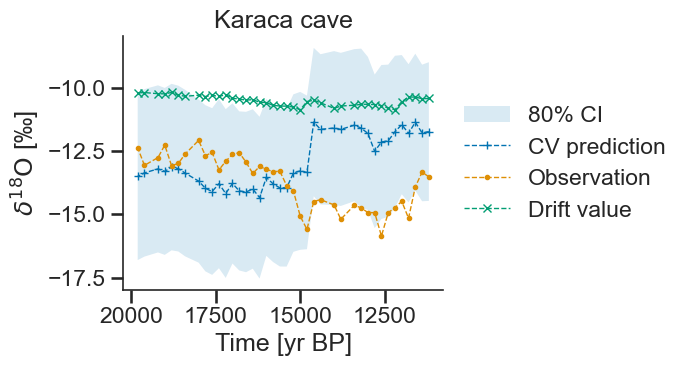

Kulishu cave nearest neighbourgh distance: 237.2355619828898


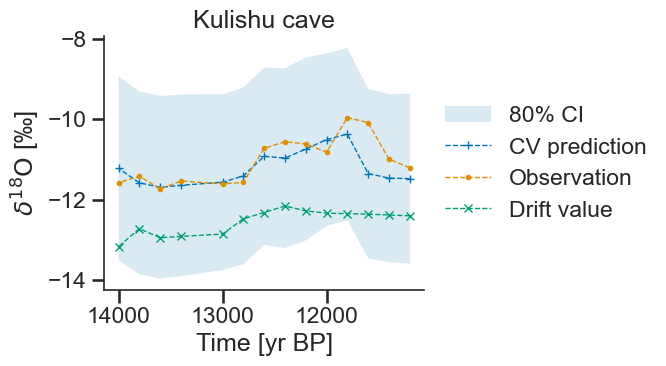

La Garma cave nearest neighbourgh distance: 13.739668483176375


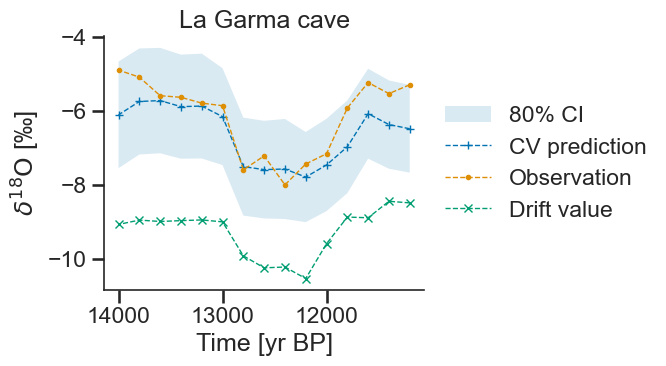

La Mine cave nearest neighbourgh distance: 722.0351753151047


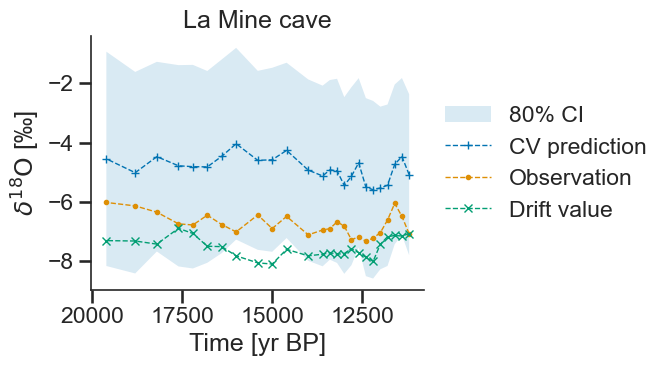

La Vallina nearest neighbourgh distance: 22.38076957730544


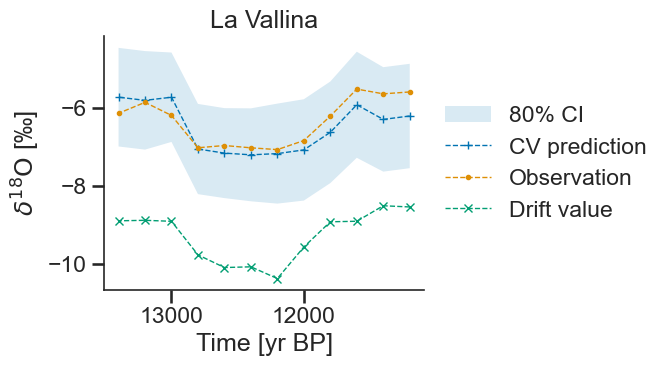

Lancaster Hole nearest neighbourgh distance: 7.845606904017933


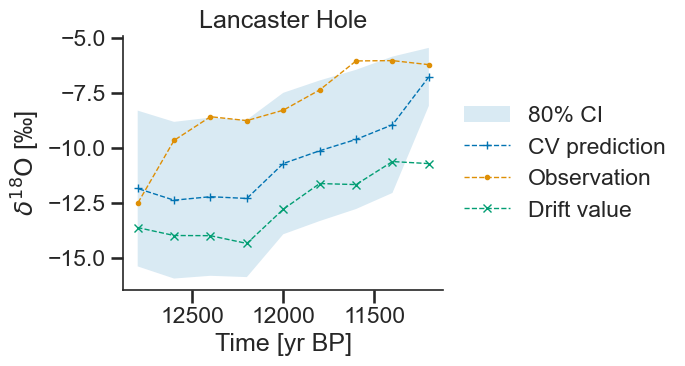

Lapa sem fim cave nearest neighbourgh distance: 552.5911834969794


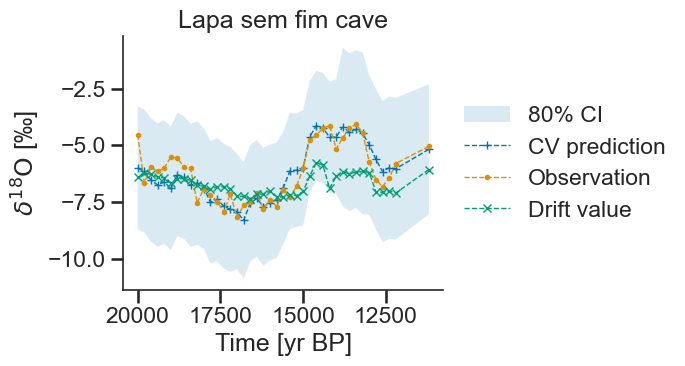

Lehman caves nearest neighbourgh distance: 171.85578228690886


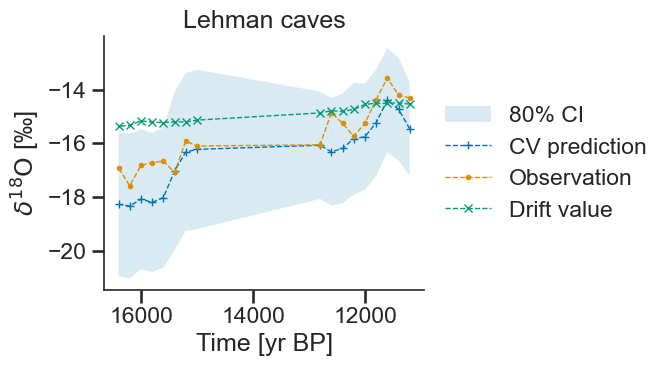

Leviathan cave nearest neighbourgh distance: 171.85578228690886


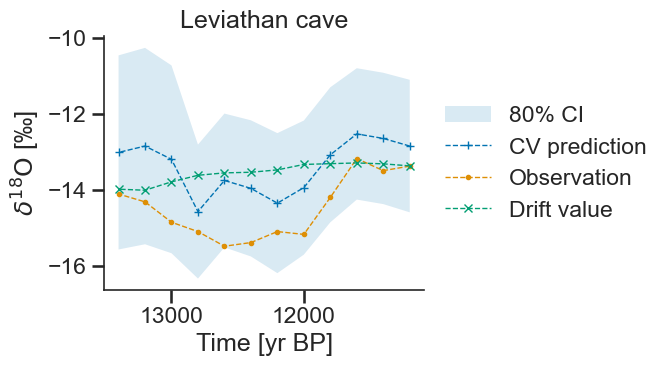

Liang Luar nearest neighbourgh distance: 395.3784849177932


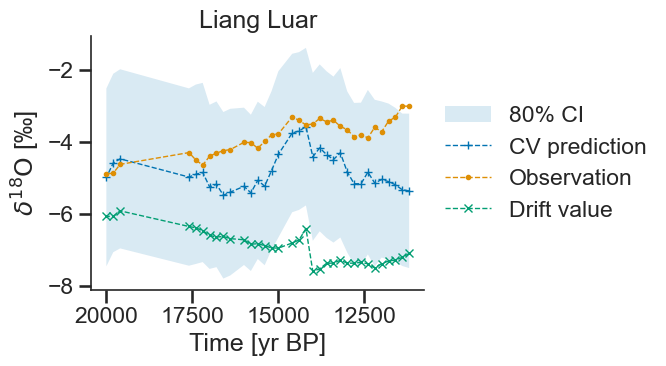

Lianhua cave, Hunan nearest neighbourgh distance: 140.63166594452107


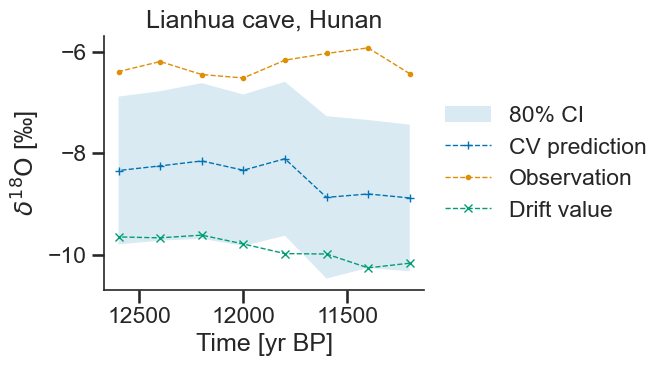

Lianhua cave, Shanxi nearest neighbourgh distance: 237.2355619828898


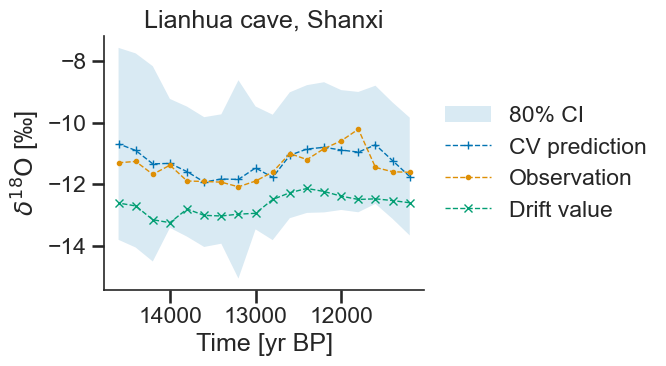

Limnon cave nearest neighbourgh distance: 501.9523693260523


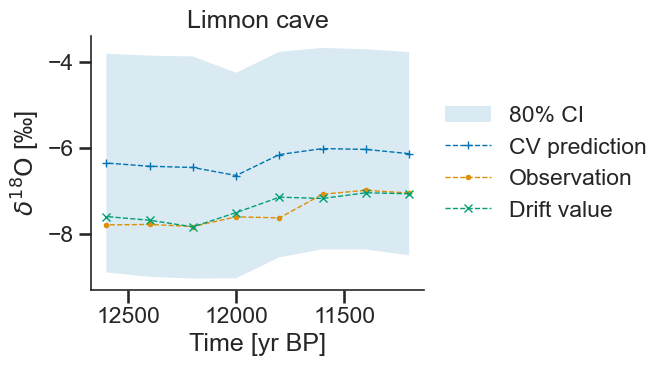

Manita peć cave nearest neighbourgh distance: 128.63355144267703


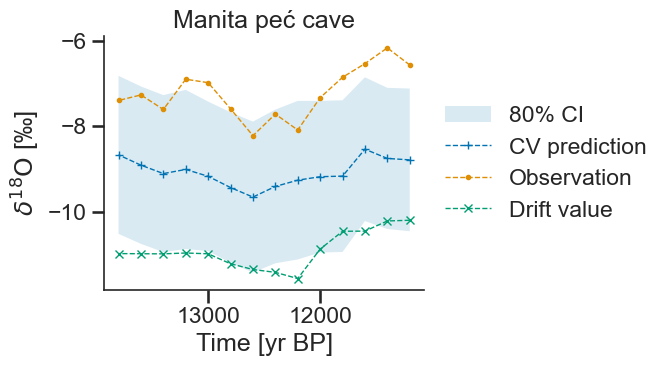

Mawmluh cave nearest neighbourgh distance: 1095.4934508101303


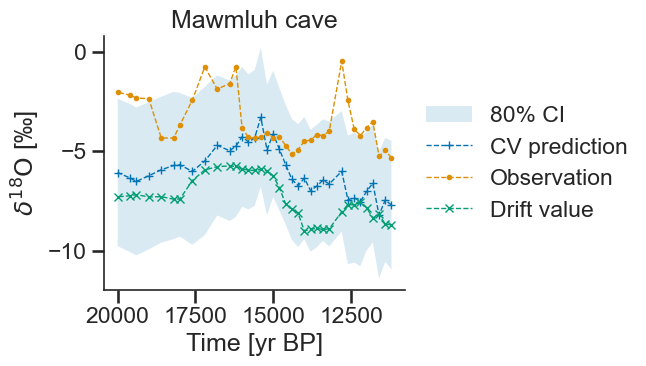

McLean's cave nearest neighbourgh distance: 3.987465659728581


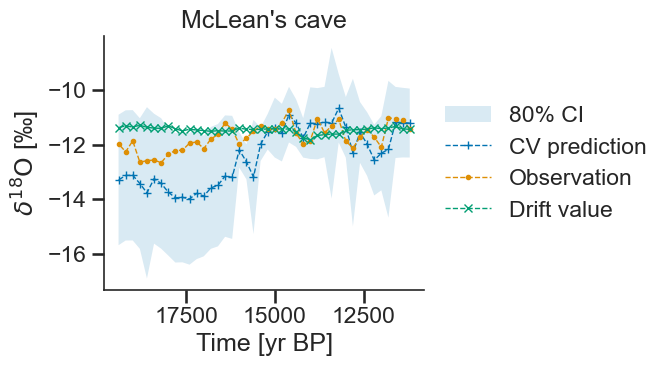

Metro cave nearest neighbourgh distance: 2.223898532891744


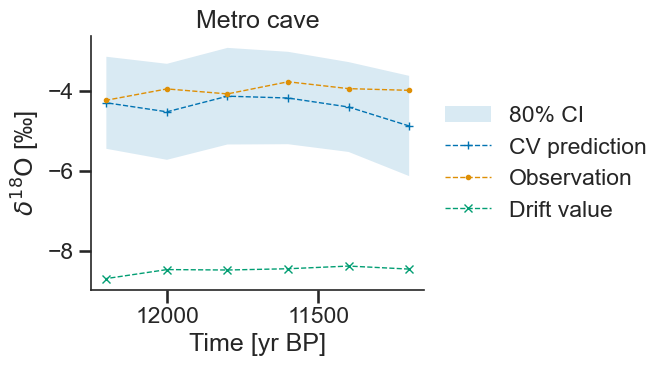

Moaning cave nearest neighbourgh distance: 3.987465659728581


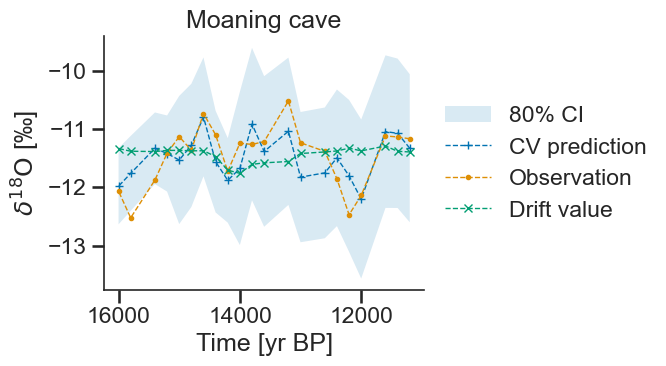

Moomi cave nearest neighbourgh distance: 2564.742523773068


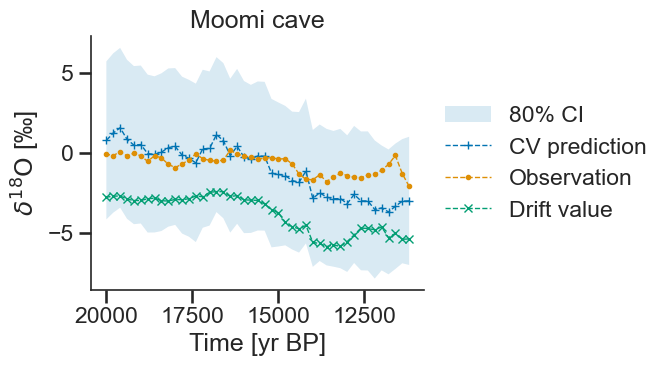

Nettlebed cave nearest neighbourgh distance: 7.110654001996641


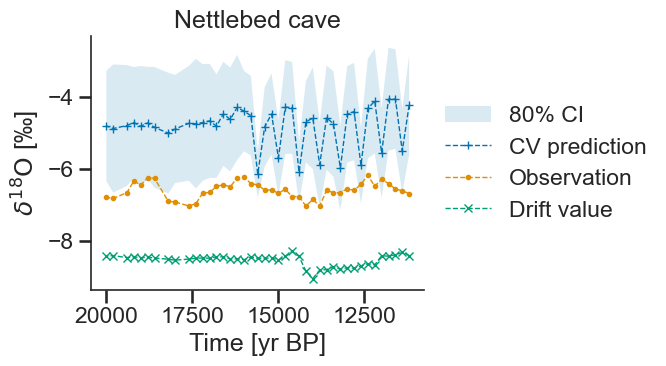

Ostolo cave nearest neighbourgh distance: 84.73137757652505


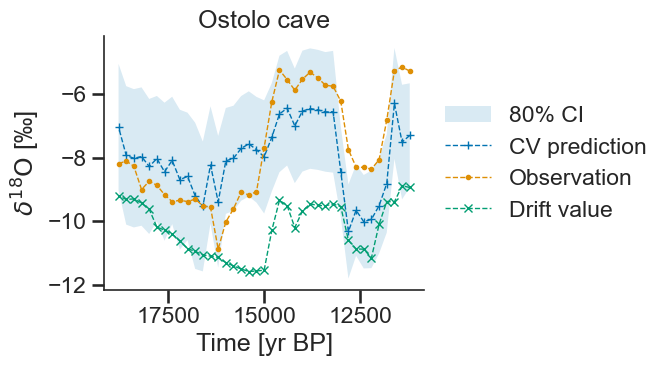

Palawan cave nearest neighbourgh distance: 813.5187368498379


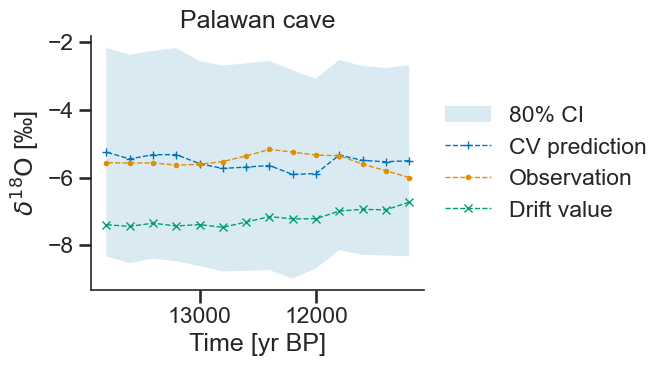

Pere Noel cave nearest neighbourgh distance: 230.36191220494825


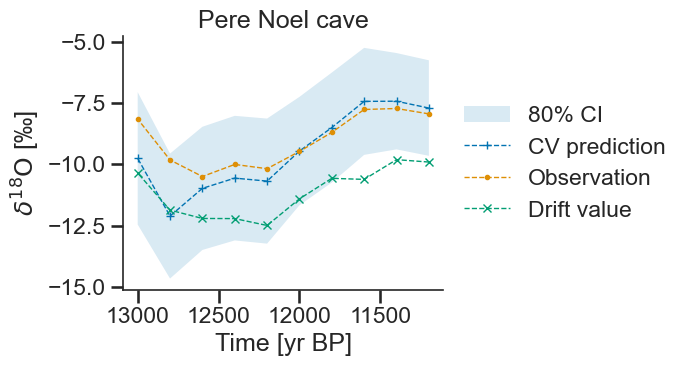

Pink Panther cave nearest neighbourgh distance: 169.07508060653032


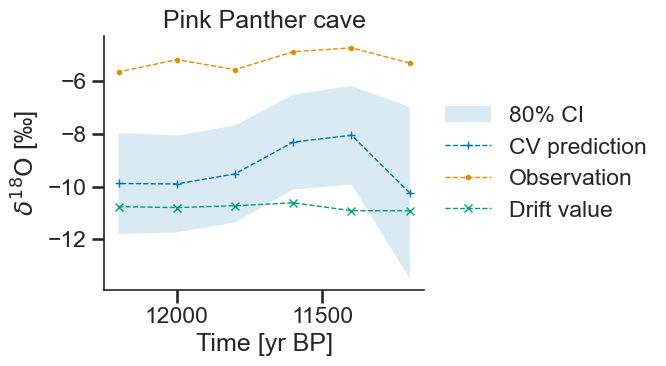

Rainha cave nearest neighbourgh distance: 2.9554293068707898


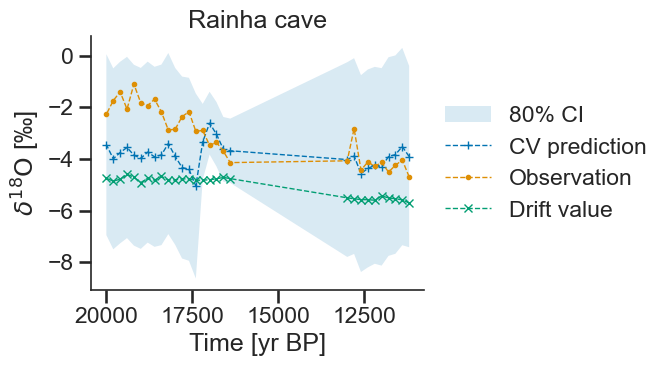

Rey Marcos nearest neighbourgh distance: 599.3322391026998


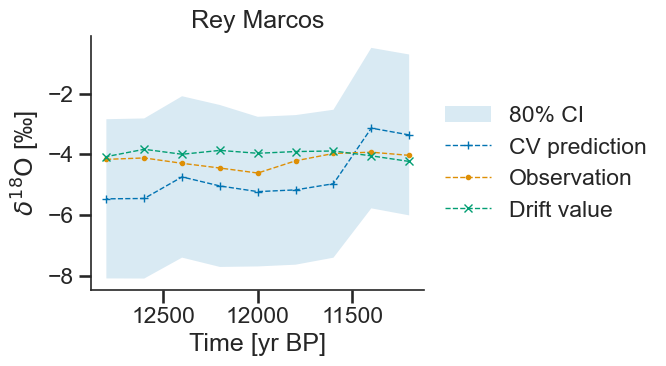

Ruakuri cave nearest neighbourgh distance: 220.22996122935388


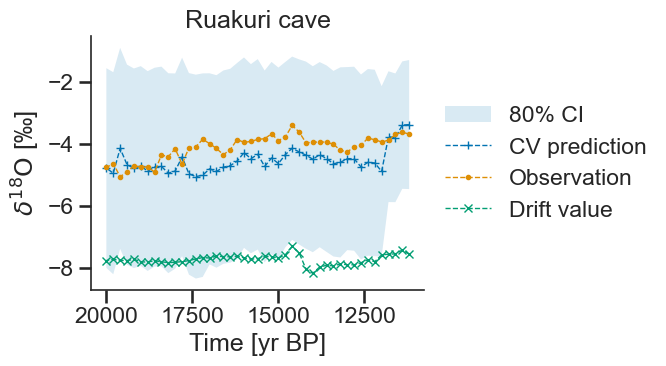

Sanbao cave nearest neighbourgh distance: 117.46176400876612


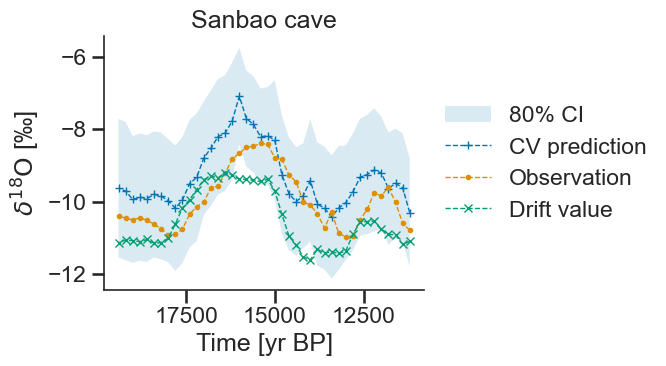

Sant'Angelo cave nearest neighbourgh distance: 501.9523693260523


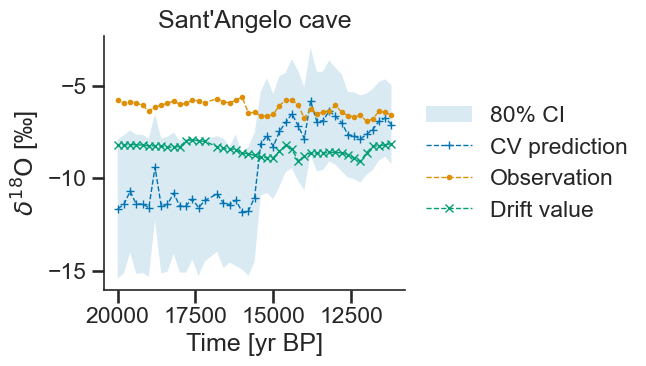

Santana cave nearest neighbourgh distance: 302.6232291967474


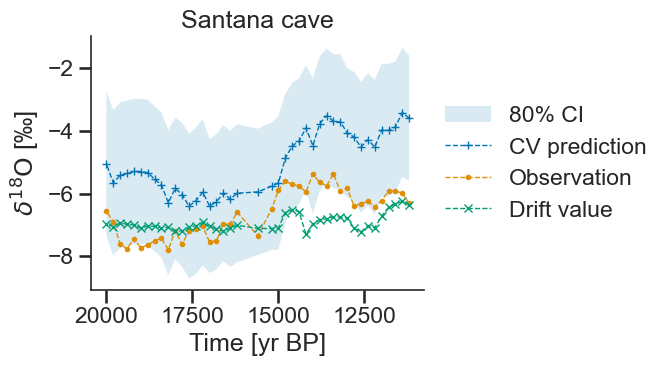

Savi cave nearest neighbourgh distance: 128.63355144267703


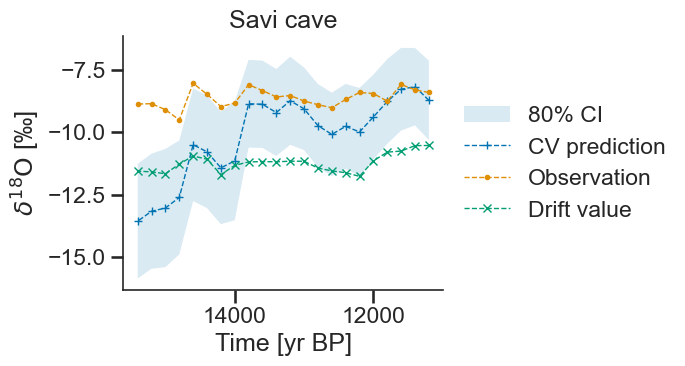

Secret cave nearest neighbourgh distance: 8.261762994230782


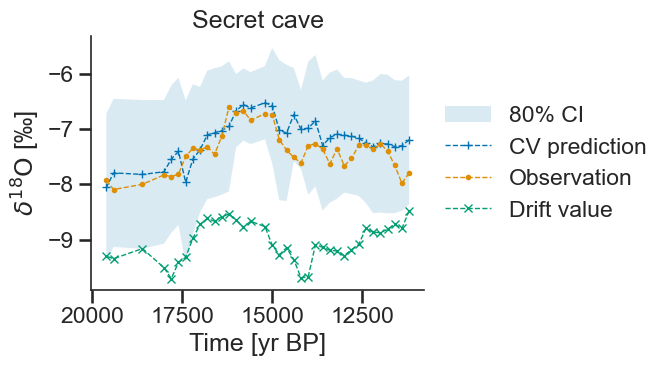

Shennong cave nearest neighbourgh distance: 459.3377314185644


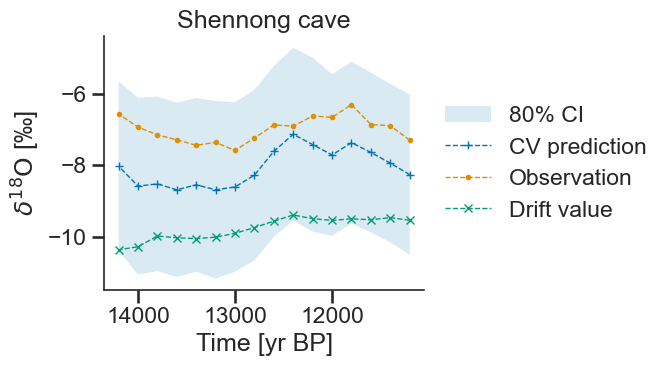

Sofular cave nearest neighbourgh distance: 543.1353656193517


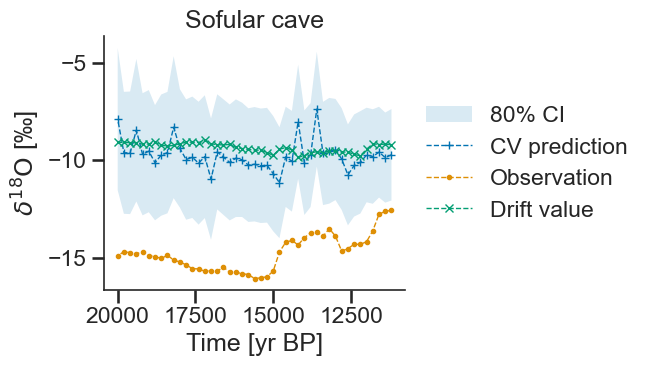

Soreq cave nearest neighbourgh distance: 12.42587055291598


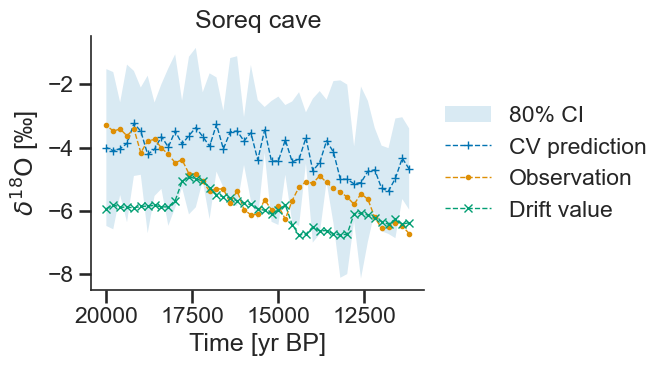

Tonnel’naya cave nearest neighbourgh distance: 866.9670355984402


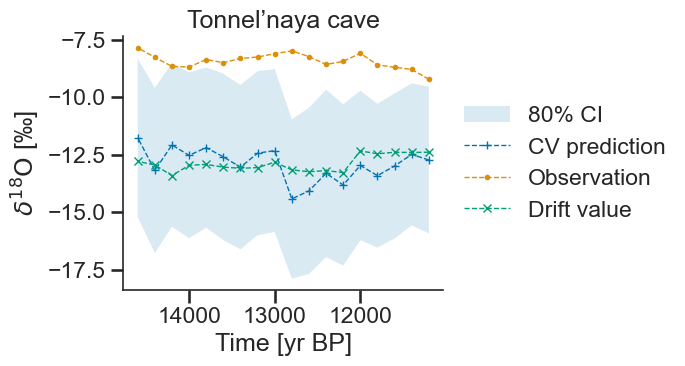

Villars cave nearest neighbourgh distance: 262.88512829976474


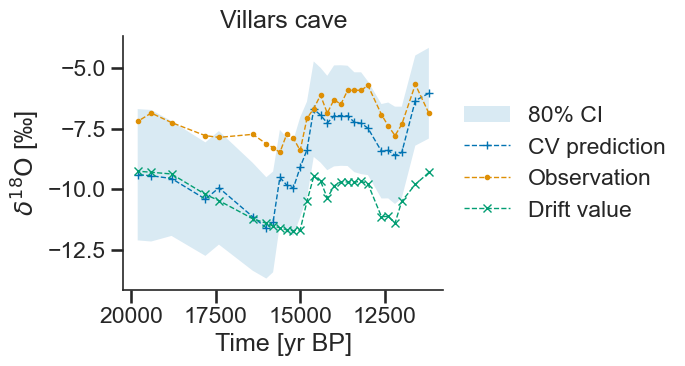

War Eagle nearest neighbourgh distance: 1294.7400646814176


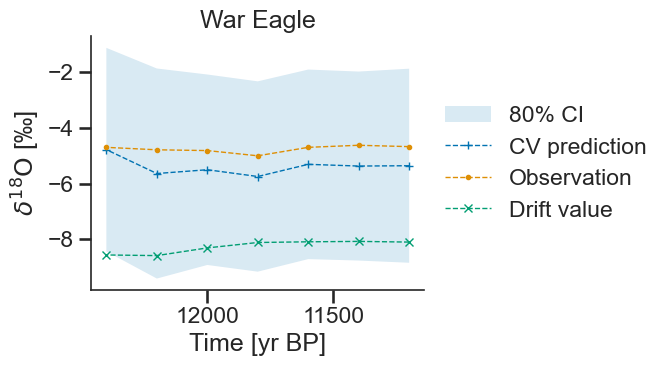

Wazpretti cave nearest neighbourgh distance: 17.653035240796594


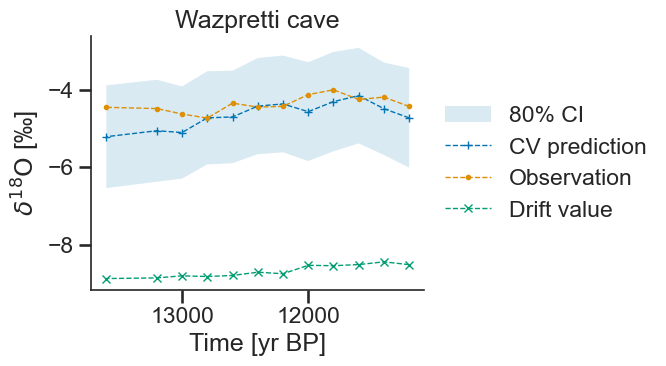

Yamen cave nearest neighbourgh distance: 28.87317596313951


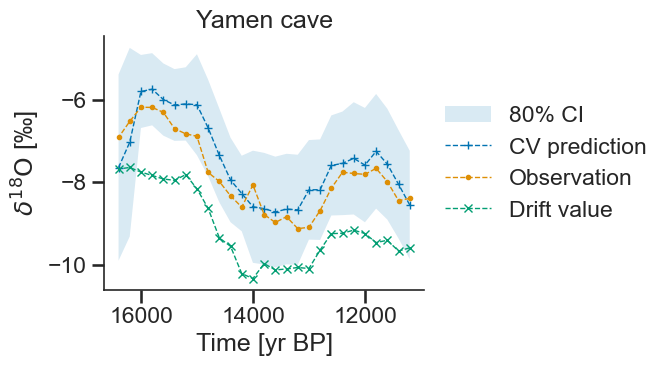

Yangzi cave nearest neighbourgh distance: 62.70871141155851


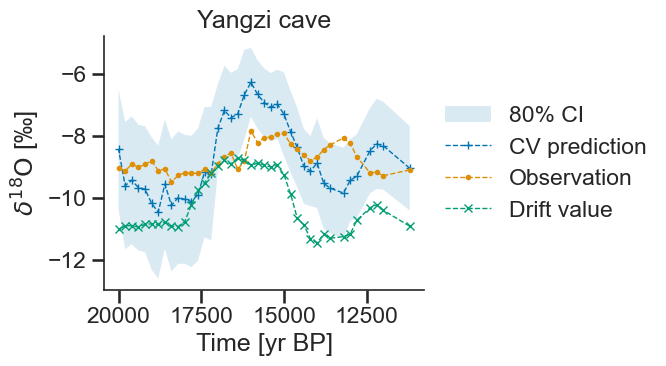

Zhuliuping cave nearest neighbourgh distance: 215.13531276950417


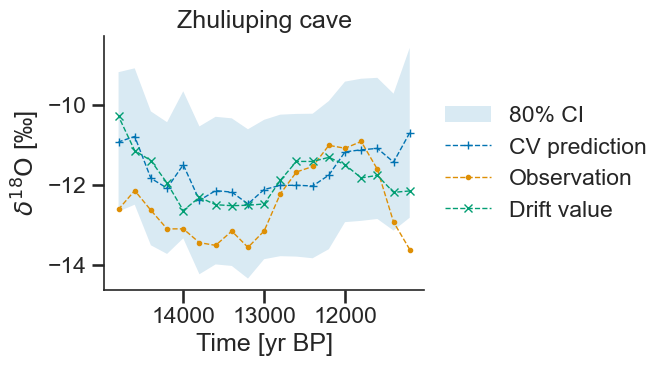

Exhaleair cave nearest neighbourgh distance: 7.110654001996641


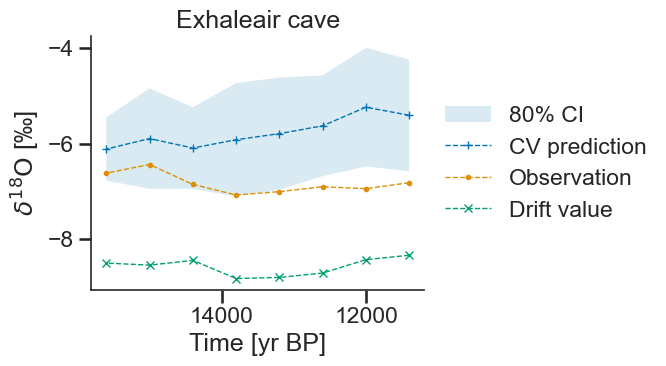

Fort Stanton cave nearest neighbourgh distance: 169.07508060653032


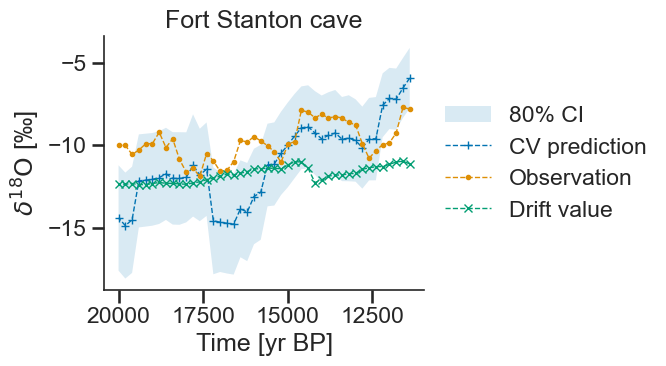

Hollywood cave nearest neighbourgh distance: 2.223898532891744


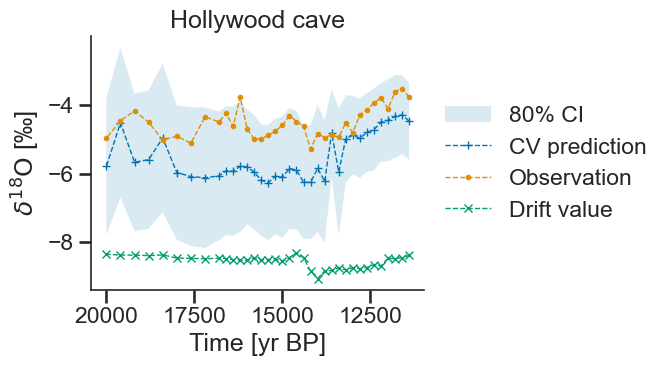

Kesang cave nearest neighbourgh distance: 1027.7794957017331


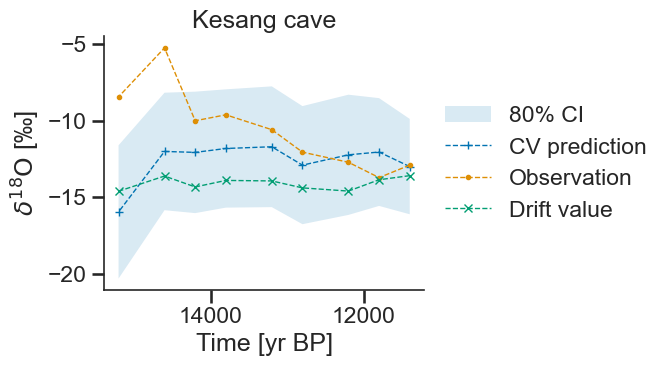

Xiaobailong cave nearest neighbourgh distance: 215.13531276950417


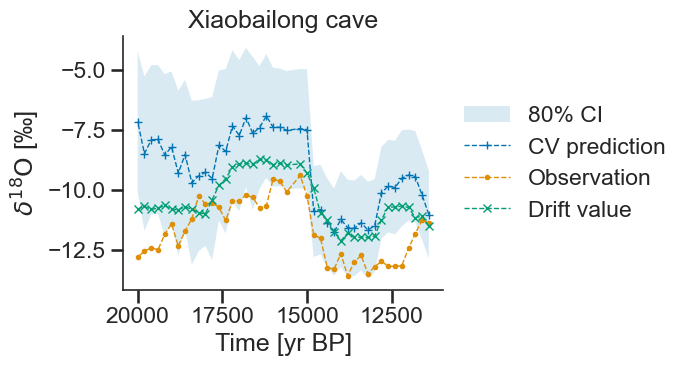

Cave of the Bells nearest neighbourgh distance: 524.7484788129576


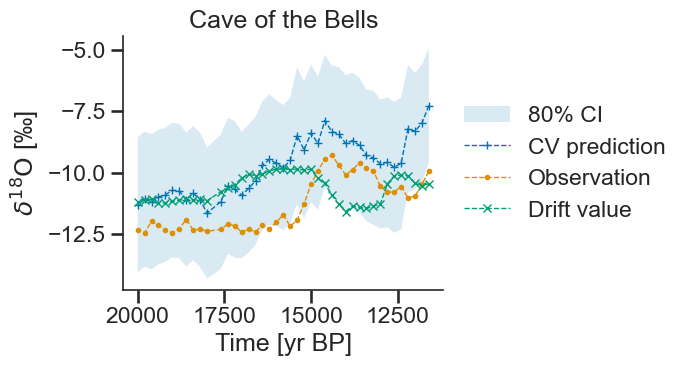

Chauvet cave nearest neighbourgh distance: 305.11447180307584


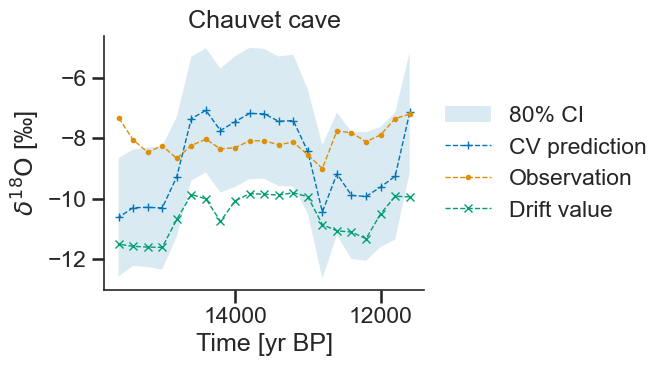

Juxtlahuaca cave nearest neighbourgh distance: 976.1796141030588


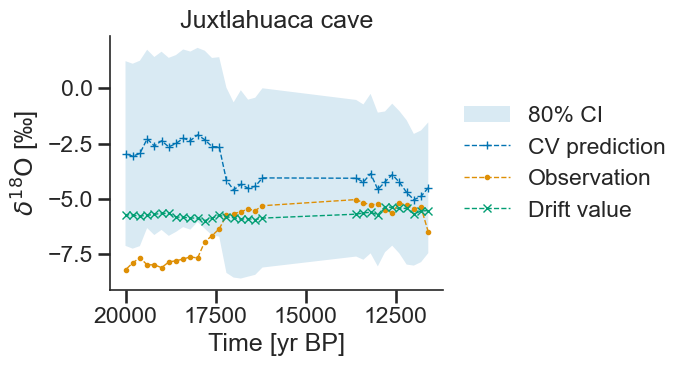

Mizpe Shelagim nearest neighbourgh distance: 71.6017072338472


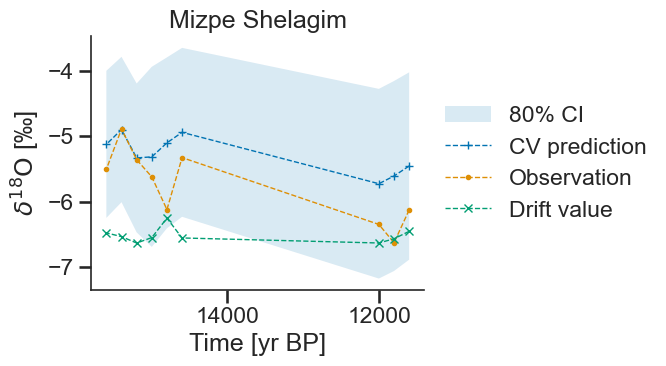

Pindal cave nearest neighbourgh distance: 15.958928653096004


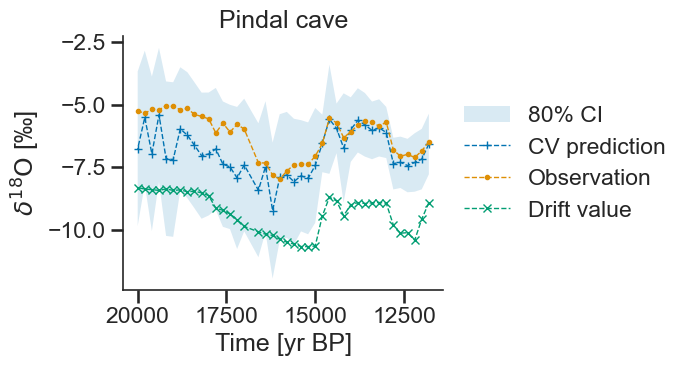

Seso cave nearest neighbourgh distance: 84.73137757652505


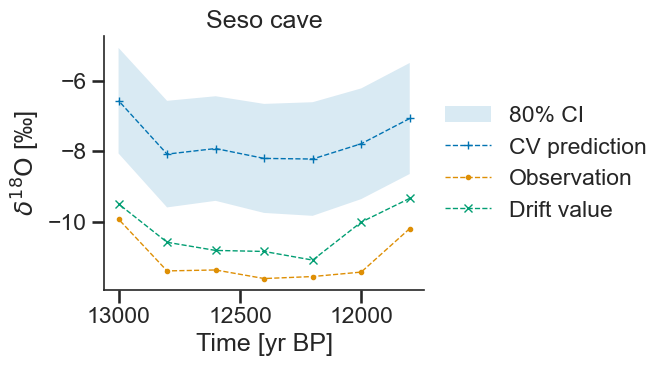

Timta cave nearest neighbourgh distance: 422.1153688845663


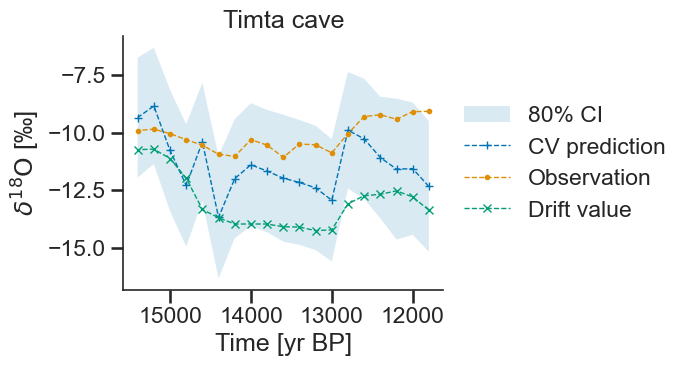

Mitoho nearest neighbourgh distance: 0.5179543279925377


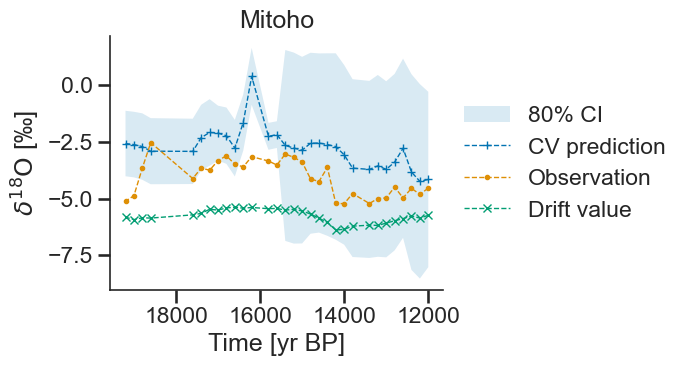

Wanxiang cave nearest neighbourgh distance: 381.3789802512567


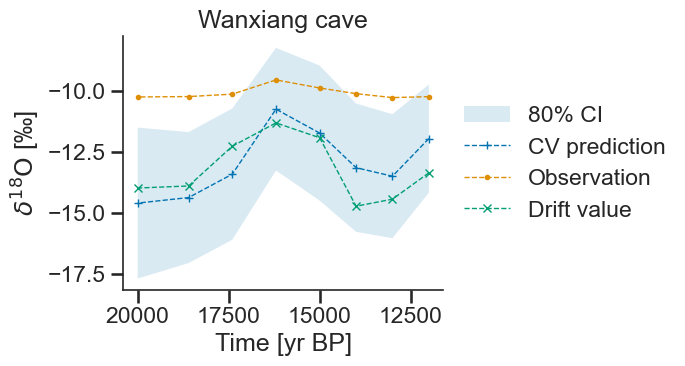

Bittoo cave nearest neighbourgh distance: 415.7898920057784


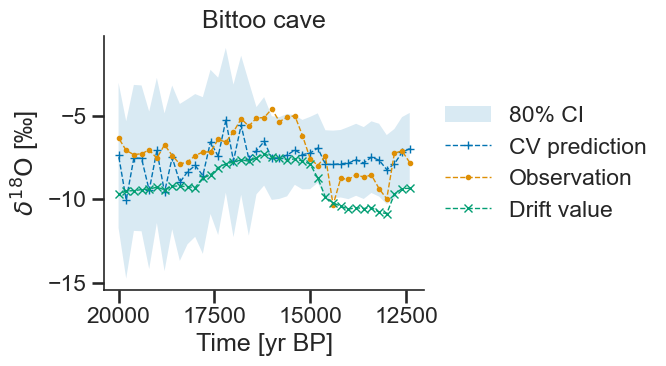

Cave Without a Name nearest neighbourgh distance: 760.505049760624


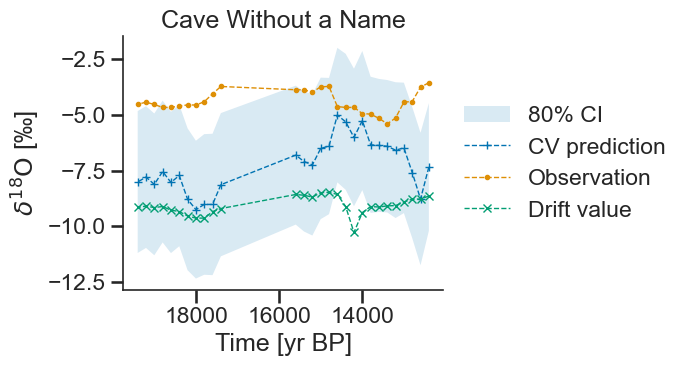

Cold Air cave nearest neighbourgh distance: 870.3639195125562


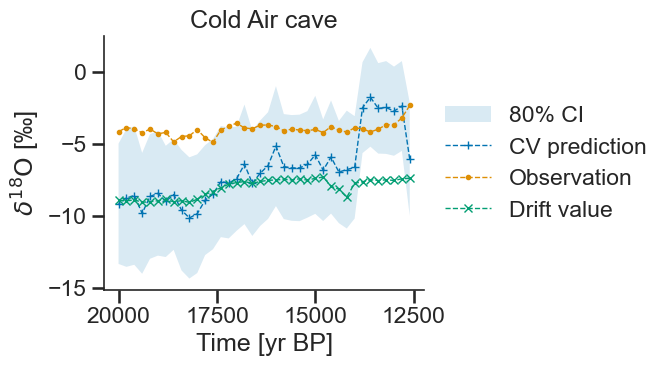

Kailash cave nearest neighbourgh distance: 604.7739565175793


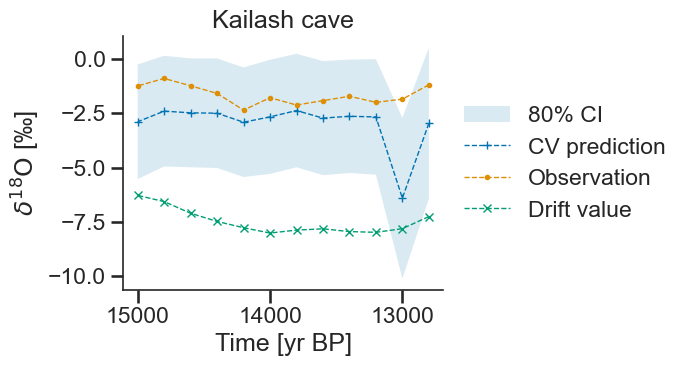

Santo Tomas cave nearest neighbourgh distance: 468.8287869172023


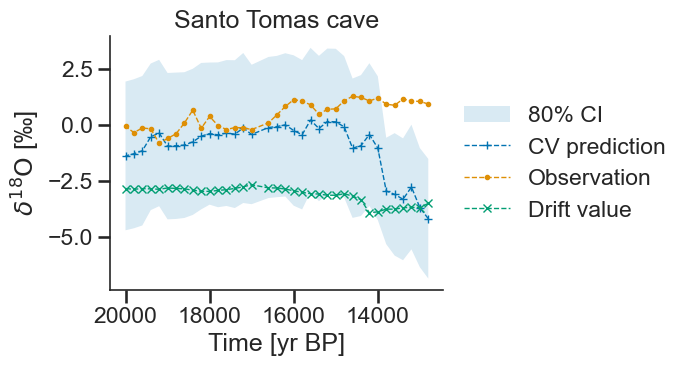

Sudwala cave nearest neighbourgh distance: 870.3639195125562


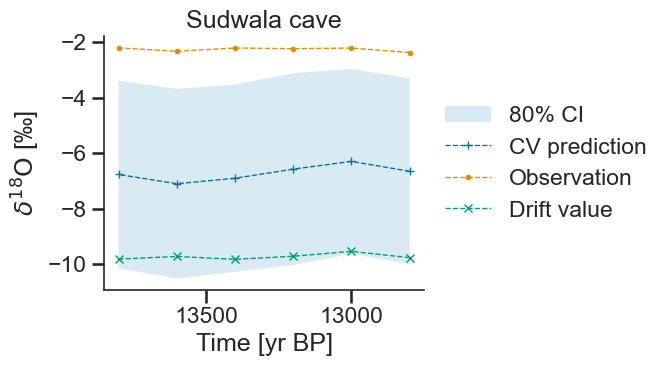

Valmiki cave  nearest neighbourgh distance: 604.7739565175793


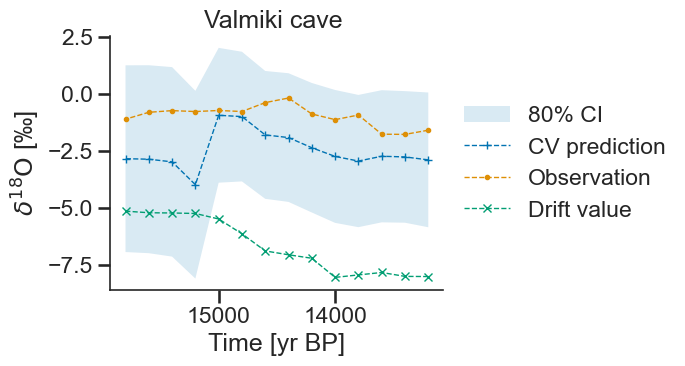

Abaco Island cave nearest neighbourgh distance: 790.4064636061543


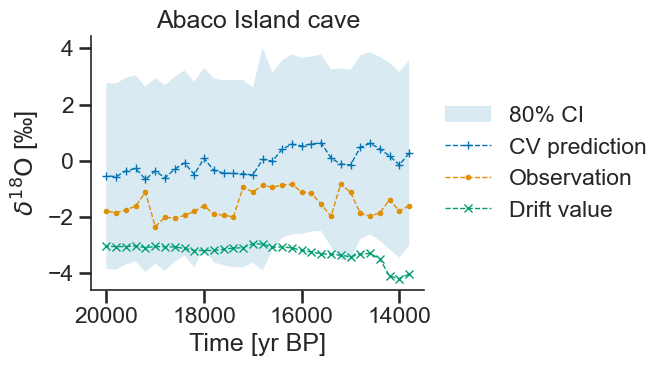

Wet Neck cave nearest neighbourgh distance: 7.783644865119334


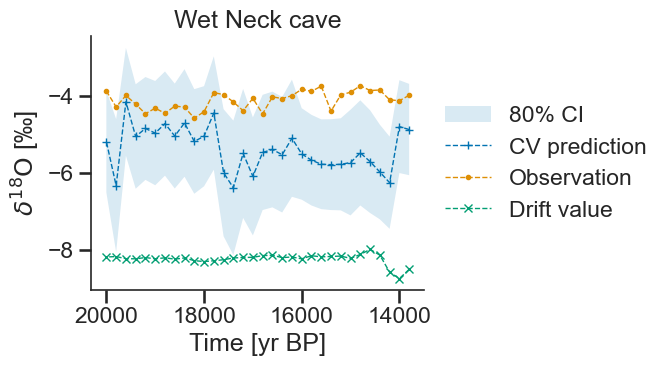

Cango cave nearest neighbourgh distance: 11.793185448852327


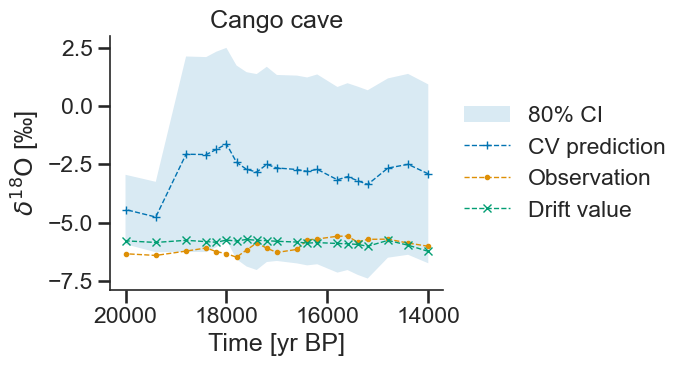

Paixão cave nearest neighbourgh distance: 552.5911834969794


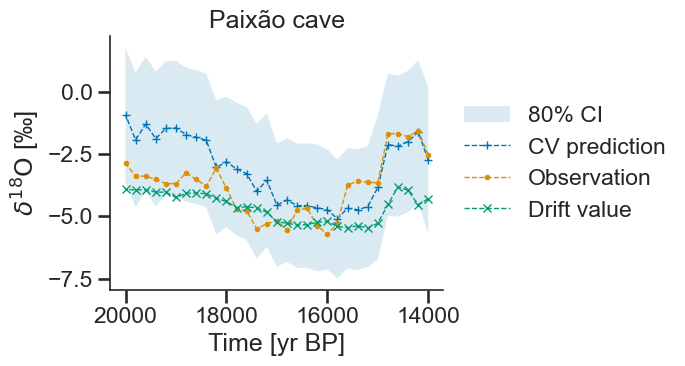

Lake Shasta cave nearest neighbourgh distance: 342.3711525772592


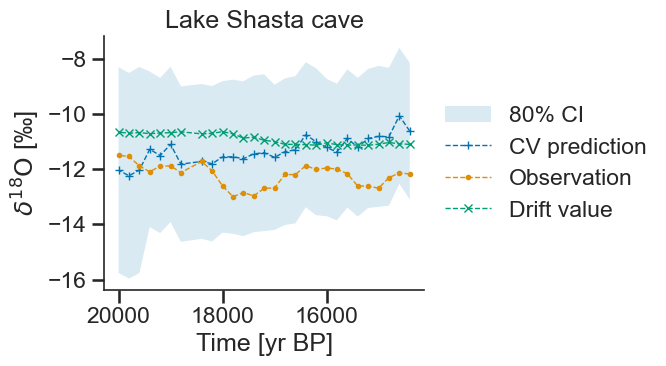

Meravelles cave nearest neighbourgh distance: 244.4687496357837


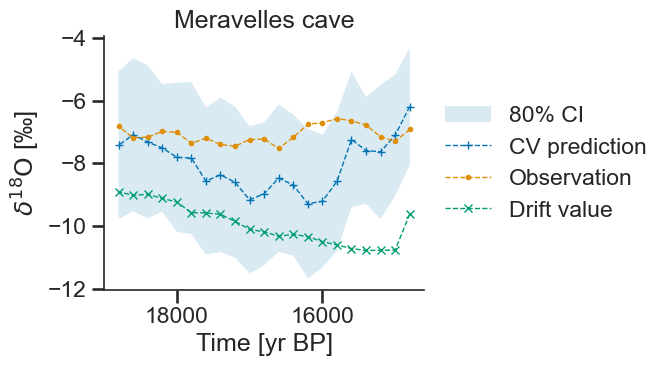

Sieben Hengste cave nearest neighbourgh distance: 190.5371248672651


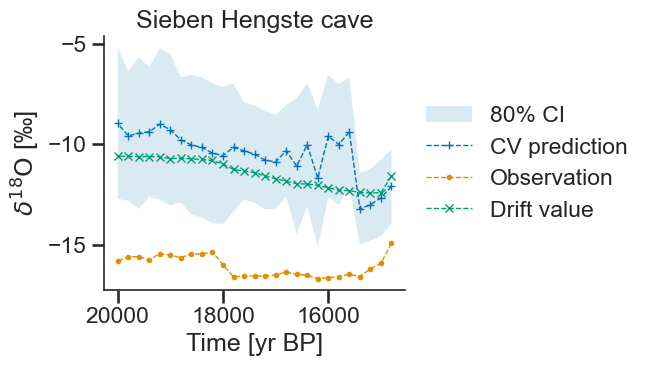

Mairs cave nearest neighbourgh distance: 2140.5644372408224


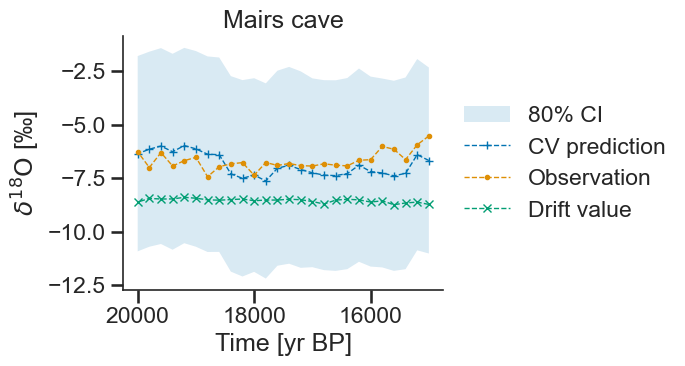

Paraiso cave nearest neighbourgh distance: 1789.676118266275


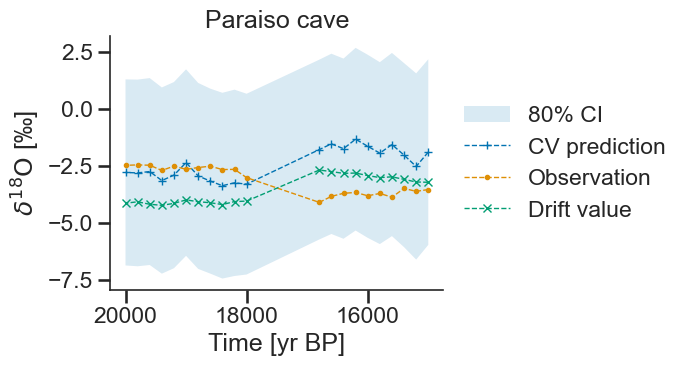

Abissal cave nearest neighbourgh distance: 2.9554293068707898


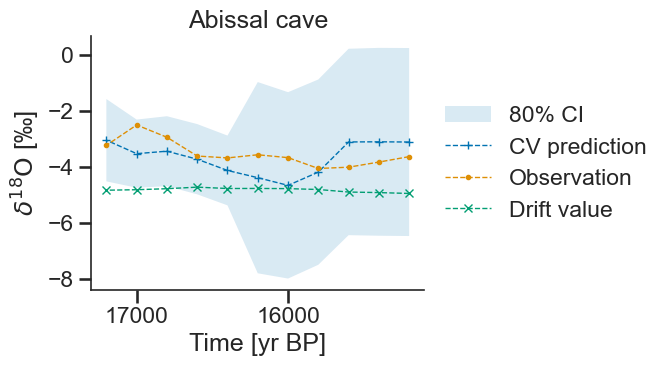

Cave C126 nearest neighbourgh distance: 1291.7810081240757


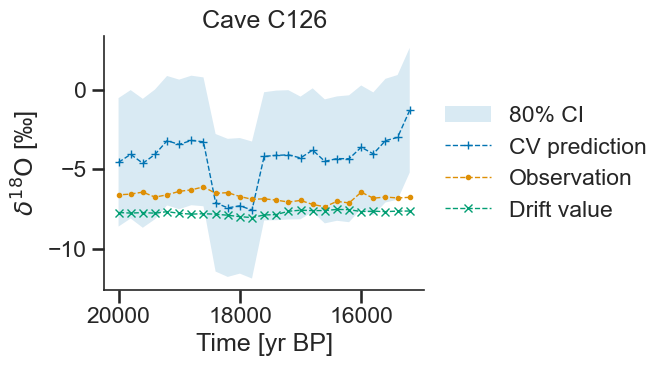

Larga cave nearest neighbourgh distance: 1380.8809779355013


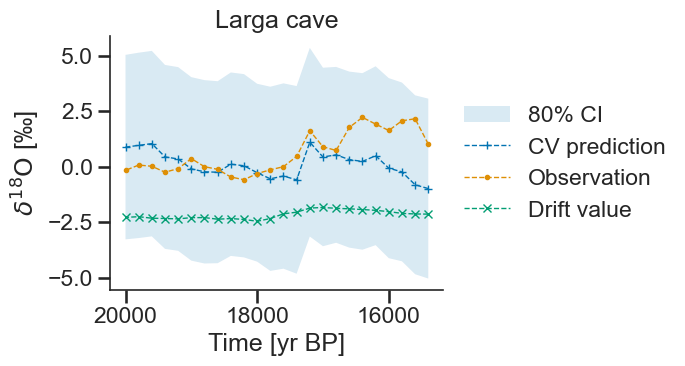

Andriamaniloke nearest neighbourgh distance: 0.5179543279925377


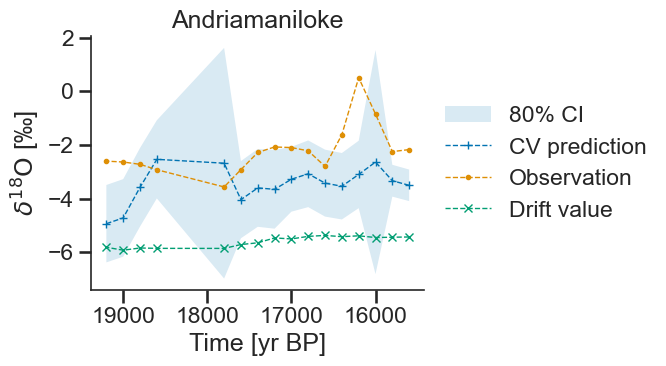

Pinnacle cave nearest neighbourgh distance: 356.38651630398226


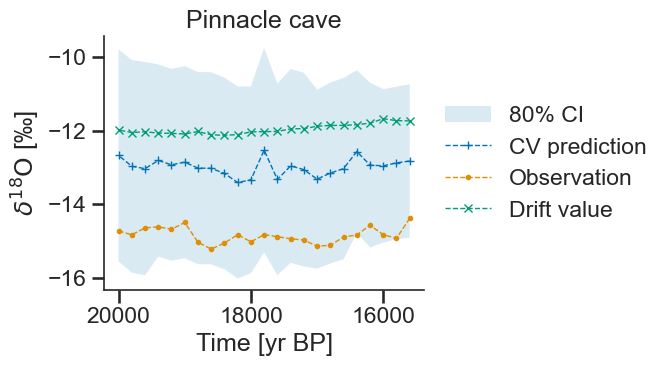

Pacupahuain cave nearest neighbourgh distance: 612.4413230623701


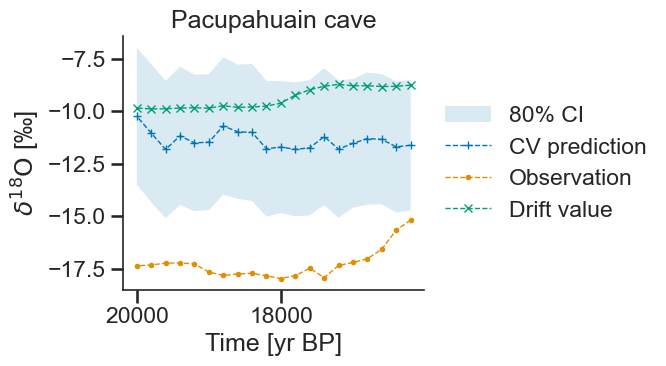

Ma'ale Efrayim cave nearest neighbourgh distance: 39.03396889286647


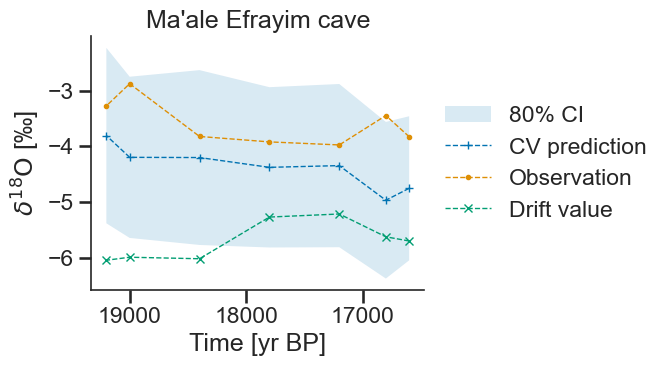

Twin Forks cave nearest neighbourgh distance: 7.783644865119334


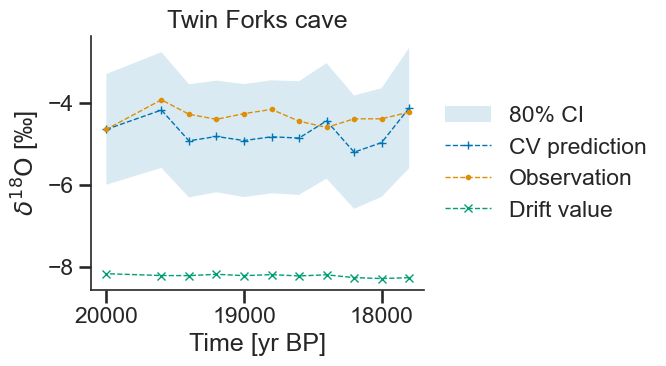

In [17]:
for num in range(len(crossval_df.site_name.unique())):
    if len(crossval_df[crossval_df.site_name==crossval_df.site_name.unique()[num]])>5:
        print(crossval_df.site_name.unique()[num], "nearest neighbourgh distance:", crossval_df.loc[crossval_df.site_name==crossval_df.site_name.unique()[num],'dist_nn'].min())
        fig,ax = plot_pred_obs_at_site_over_time(crossval_df,crossval_df.site_name.unique()[num]) 
        plt.tight_layout()
        # plt.savefig('../output/results_figs/obs_pred_drift_PinkPantherCave.png',dpi=500)
        plt.show()

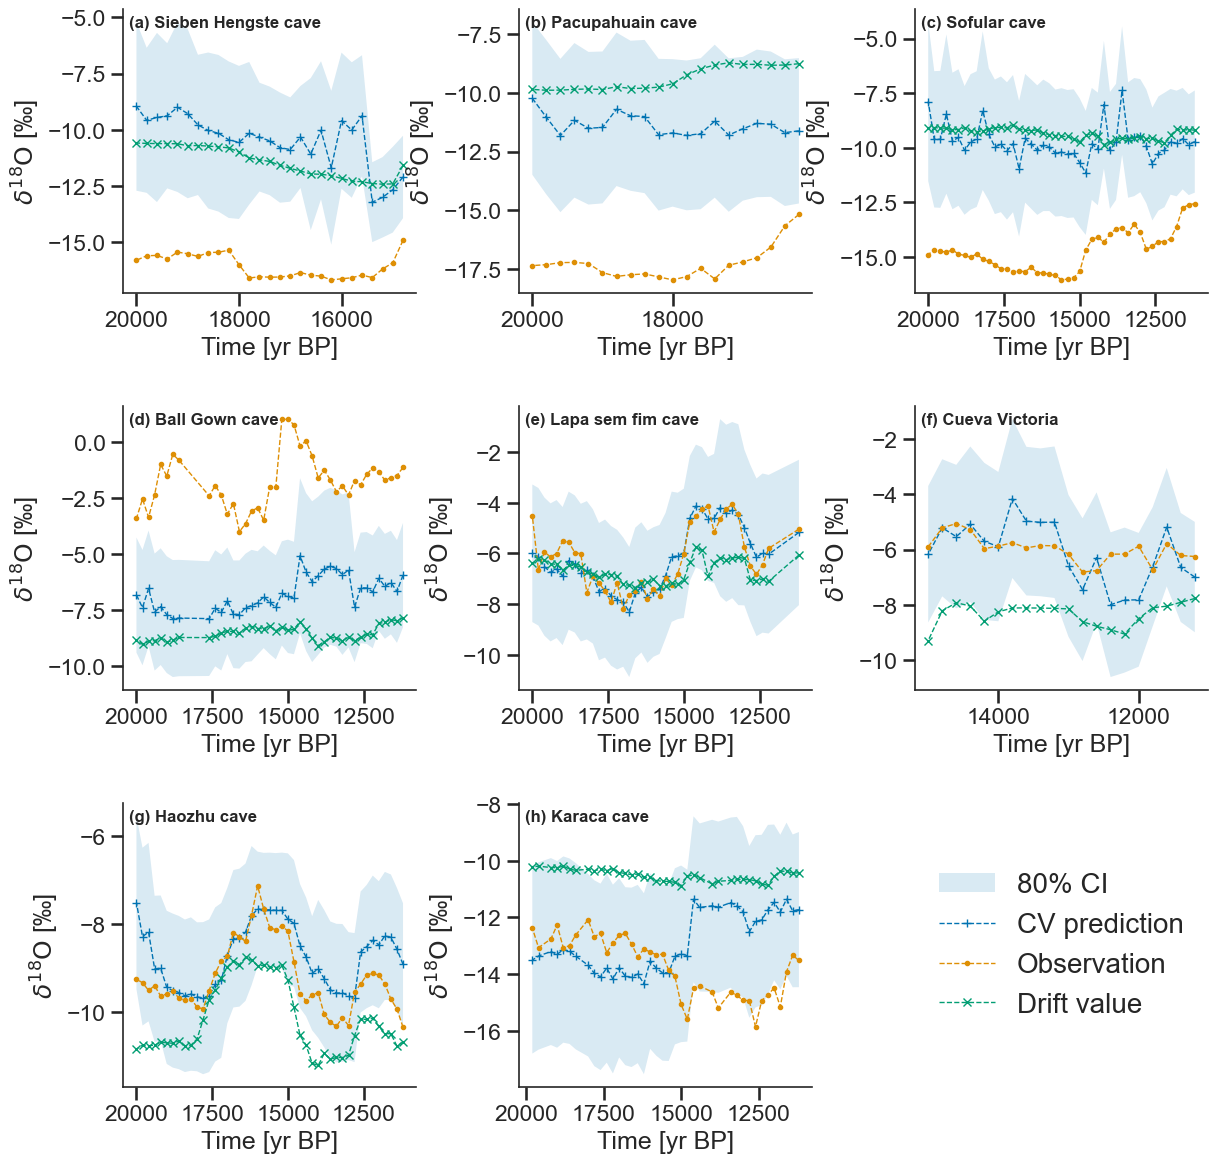

In [66]:
#### Fig for essd : Sieben Hengste cave, Ball Gown cave, Victoria cave, Haozhu, Jaraguá cave, Lapa sem fim cave, Liang Luar, Ruakuri cave
from matplotlib.gridspec import GridSpec

def plot_essd_examples(crossval_df, site_name,fig=None,ax=None, legend=False):
    df_site = crossval_df.loc[crossval_df.site_name == site_name].sort_values('time').copy()
    if fig is None or ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))

    sigma = np.sqrt(np.clip(df_site['ss_pred'].values, 0, None))
    z_pred = df_site['z_pred'].values
    ci = 1.28 * sigma

    ax.fill_between(
        df_site.time.values,
        z_pred - ci,
        z_pred + ci,
        color='C0',
        edgecolor='none',
        alpha=0.15,
        label='80% CI',
    )
    ax.plot(df_site.time.values, z_pred, '--+', linewidth=1., markersize=6, label='CV prediction')
    ax.plot(df_site.time.values, df_site['z_obs'].values, '--.', linewidth=1., markersize=6, label='Observation')
    ax.plot(df_site.time.values, df_site['drift_at_obs'].values, '--x', linewidth=1., markersize=6, label='Drift value')

    ax.set_xlabel('Time [yr BP]')
    ax.set_ylabel(r'$\delta^{18}\text{O}$ [‰]')
    ax.invert_xaxis()
    sns.despine()
    if legend :
        ax.legend(frameon=False, loc='center left', bbox_to_anchor=(0.1, 0.5))

    return fig, ax


sites_to_plot = ['Sieben Hengste cave', 'Pacupahuain cave','Sofular cave','Ball Gown cave','Lapa sem fim cave','Cueva Victoria', 'Haozhu cave','Karaca cave']#, 'Cueva Victoria', 'Haozhu cave', 'Jaraguá cave', 'Lapa sem fim cave', 'Liang Luar', 'Ruakuri cave']
indices = ['(a)','(b)','(c)','(d)','(e)','(f)','(g)','(h)']
fig = plt.figure(figsize=(14, 14))
gs = GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.35)

# Add 8 plot subplots (all square)
axes = []
for i in range(8):
    row = i // 3
    col = i % 3
    axes.append(fig.add_subplot(gs[row, col]))

# Legend subplot
ax_legend = fig.add_subplot(gs[2, 2])
ax_legend.axis('off')

for i, site in enumerate(sites_to_plot):    
    ax = axes[i]
    ax.text(0.02, 0.98, indices[i]+f" {site}", transform=ax.transAxes, fontsize=12, fontweight='bold', va='top', ha='left')
    fig_site, ax_site = plot_essd_examples(crossval_df, site, fig, ax, legend=False)

# Add legend to the legend subplot
handles, labels = axes[0].get_legend_handles_labels()
ax_legend.legend(handles, labels, loc='center', ncol=1, frameon=False, fontsize=20)

plt.savefig('../output/essd_figs/fig_ts_examples.png',dpi=300)
plt.show()

#### Statistical test results 
In the cel below, we investigate whether the statistical was failed in some time slices, and because of which sites.

In [5]:
crossval_df[crossval_df['|PES| > critical_val']]

,Unnamed: 0,site_name,lon,lat,z_pred,ss_pred,z_obs,drift_at_obs,ele (SISAL),ele (iTraCE),dist_nn,residual,PES,|PES| > critical_val,ci,time
1,1,Ball Gown cave,125.0000,-17.0300,-6.979162,3.849954,0.761199,-8.374715,100.0,290.037849,431.804831,-7.740361,3.944877,True,6.556416,14800
1,1,Ball Gown cave,125.0000,-17.0300,-6.905091,3.913980,1.000173,-8.429297,100.0,290.037849,431.804831,-7.905264,3.995830,True,6.654543,15000
2,2,Ball Gown cave,125.0000,-17.0300,-6.773677,3.312465,1.010892,-8.264403,100.0,297.210538,431.804831,-7.784570,4.277194,True,6.114084,15200
27,27,Jerusalem west cave,35.1500,31.7833,-5.540408,0.307539,-3.439740,-6.015350,700.0,434.836422,12.425871,-2.100668,3.787978,True,1.865344,15400
58,58,Soreq cave,35.0226,31.7558,-3.441245,0.317763,-5.644329,-5.980811,400.0,423.277459,12.425871,2.203085,-3.908223,True,1.896098,15400
53,53,Sieben Hengste cave,7.8100,46.7500,-9.382104,4.443569,-16.478550,-12.321735,1955.0,795.463473,393.742652,7.096446,-3.366472,True,7.062928,15600
21,21,Jerusalem west cave,35.1500,31.7833,-5.813277,0.341598,-3.852883,-5.793972,700.0,434.836422,12.425871,-1.960394,3.354175,True,1.944636,16000
51,51,Soreq cave,35.0226,31.7558,-3.795300,0.348136,-5.956629,-5.762671,400.0,423.277459,12.425871,2.161329,-3.663077,True,1.963158,16000
2,2,Andriamaniloke,43.7569,-24.0510,-3.093960,0.963862,0.514581,-5.382150,20.0,206.584760,0.517954,-3.608541,3.675565,True,3.271296,16200
35,35,Mitoho,43.7533,-24.0477,0.396550,0.963721,-3.142403,-5.383204,20.0,206.651594,0.517954,3.538953,-3.604950,True,3.271055,16200


0.7777777777777778

In [6]:
crossval_df.loc[crossval_df['|PES| > critical_val'],'site_name'].unique()

array(['Ball Gown cave', 'Jerusalem west cave', 'Soreq cave',
       'Sieben Hengste cave', 'Andriamaniloke', 'Mitoho'], dtype=object)

In [7]:
crossval_df.loc[crossval_df['|PES| > critical_val'],'time'].unique()

array([14800, 15000, 15200, 15400, 15600, 16000, 16200, 16800, 18600,
       18800])

#### Vizualise kriged dataset

In this section, we open the dataset .nc file that was created by running the script ```kriging.py``` and we plot some isoscapes.

In [ ]:
kriged_ds = utils.load_xarray_datarray(fn='../output/kriging/runs_wip/2026-05-18/scaling_factor/res200/speleothems_isoscapes_11_to_20kaBP.nc')

In [10]:
d18Op = kriged_ds.d18Op
d18Op_var = kriged_ds.ss_pred
confidence_flags = kriged_ds.confidence_flag

In [11]:
kriged_ds.time

<xarray.DataArray 'time' (time: 45)> Size: 360B
array([11200., 11400., 11600., 11800., 12000., 12200., 12400., 12600., 12800.,
       13000., 13200., 13400., 13600., 13800., 14000., 14200., 14400., 14600.,
       14800., 15000., 15200., 15400., 15600., 15800., 16000., 16200., 16400.,
       16600., 16800., 17000., 17200., 17400., 17600., 17800., 18000., 18200.,
       18400., 18600., 18800., 19000., 19200., 19400., 19600., 19800., 20000.])
Coordinates:
  * time     (time) float64 360B 1.12e+04 1.14e+04 1.16e+04 ... 1.98e+04 2e+04
Attributes:
    units:        years
    description:  Years before Present (1950). Positive integers.

In [12]:
kriged_df = kriged_ds.to_dataframe().reset_index().dropna()

In [13]:
kriged_df.columns

Index(['time', 'lat', 'lon', 'd18Op', 'ss_pred', 'confidence_flag'], dtype='object')

In [14]:
kriged_df['std']=np.sqrt(kriged_df.ss_pred)

In [15]:
# Compare to itrace values

# load all itrace simulation data 
with open(f'{utils.get_project_root()}/data/iTrace_simulations_dict.json', 'r') as f:
    itrace_sims = json.load(f)
df_list = []
for kyr,dict_ in itrace_sims.items() :
    if kyr !='_comment':
        print(f'=== {kyr} ka BP ===')
        itrace_df  = geostat_utils.get_preprocessed_itrace_data(
                true_kyr=int(float(kyr)),
                res=200,
                data_folder='/media/luluxette/T7_Shield/pdm/iTrace/',
                format='df',
                amount_weighted=True,
                verbose=False,
                sim_suffix =dict_['suffix'], 
                sim_forcings=dict_['forcings'],
                sim_kyr= int(dict_['yrBPname']),
                sim_num=dict_['num'],
                sim_model='clm2.h0',
            )
        if any(itrace_df.lon > 180): itrace_df['lon'] =  utils.convert_lon_0_360_to_neg180_180(itrace_df.lon.values) #type:ignore
        
        itrace_slice = itrace_df.rename(columns={'d18Op':'itrace_d18Op'}) # type:ignore
        df_list.append(itrace_slice)
    
kriged_df = kriged_df.rename(columns= {'d18Op':'kriged_d18Op'})
itrace_df_all = pd.concat(df_list)
merged_df = pd.merge(left=kriged_df[['lat','lon','kriged_d18Op','time']],right=itrace_df_all[['lat','lon','itrace_d18Op','time']],how='outer',on=['lat','lon','time']) #type:ignore
merged_df['diff'] = (merged_df.kriged_d18Op - merged_df.itrace_d18Op)/np.abs(merged_df.itrace_d18Op)
merged_df.dropna(subset='diff',inplace=True)


=== 12 ka BP ===


KeyboardInterrupt: 

In [42]:
merged_df.to_csv('/media/luluxette/T7_Shield/pdm/merged_df_kriged_itrace_2026-05-19.csv',index=False)

In [43]:
merged_df = pd.read_csv('/media/luluxette/T7_Shield/pdm/merged_df_kriged_itrace_2026-05-19.csv')

In [44]:
mean_merged_df = merged_df.groupby(['lon', 'lat'],as_index=False).mean()

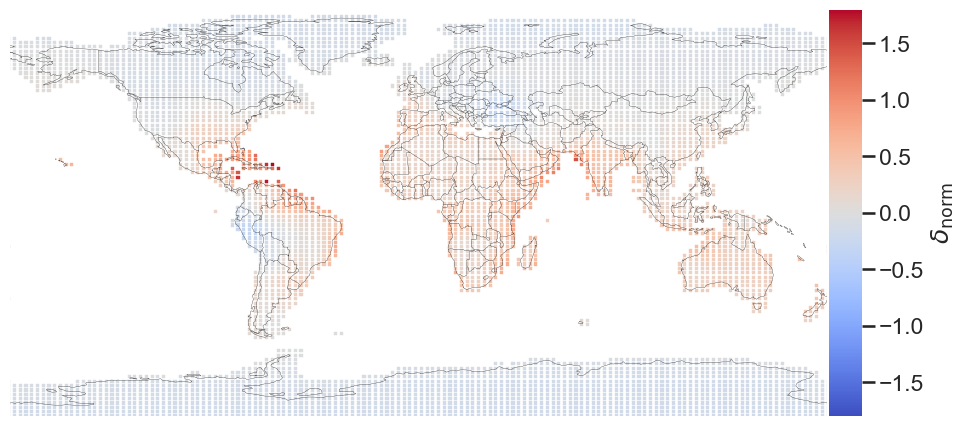

In [ ]:
plot_utils.plot_latlon_platecarree_df(
    mean_merged_df,#mean_merged_df.lon.between(-100,-63))& (mean_merged_df.lat.between(12,31))],
    qty_col='diff',
    qty_label=r'$\delta_\text{norm}$',
    cmap='coolwarm',
    s=10,
    cmap_sym0=True,
    title=None,
    unit=None,
    countries_borders=True,
    oceancolor="#FFFFFF",
    landcolor="#FFFFFF",
)
plt.tight_layout()
# plt.savefig('../output/kriged_isoscape_norm_diff_all_times.png',dpi=500)
plt.show()

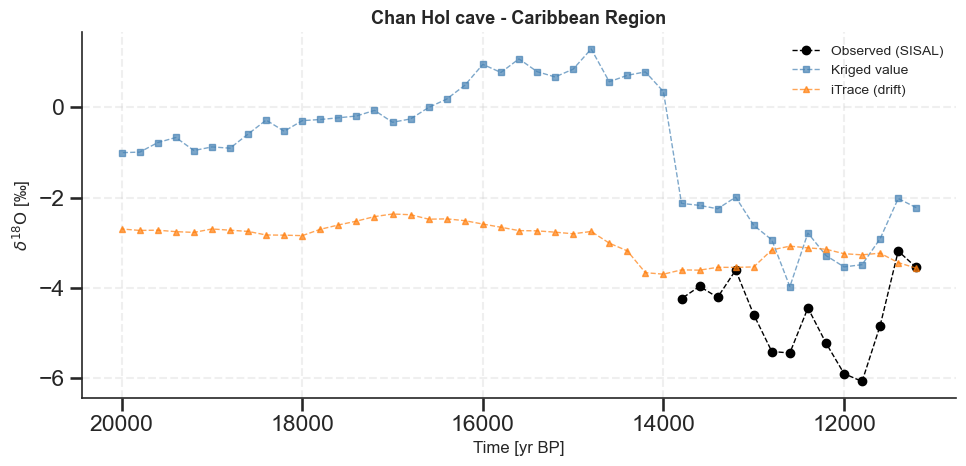

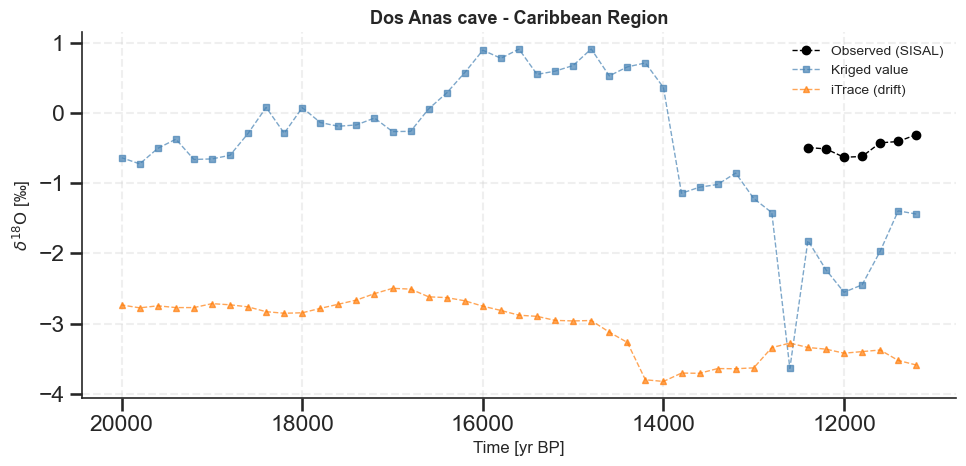

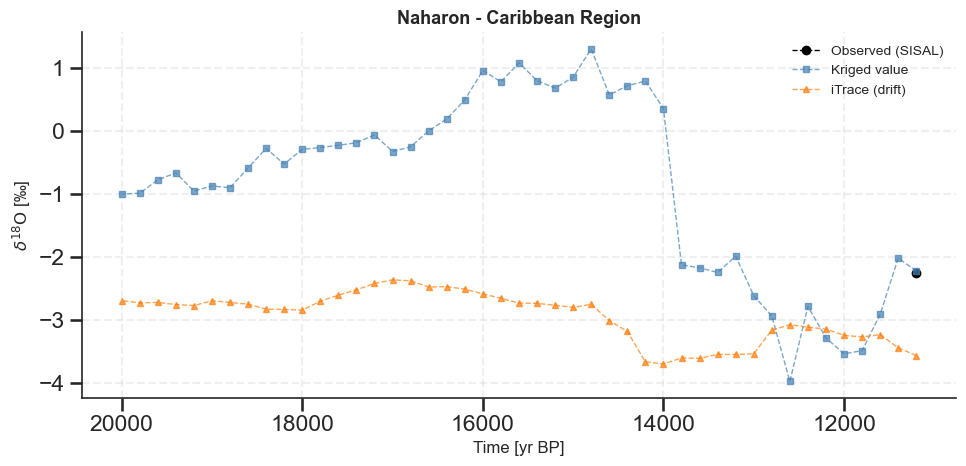

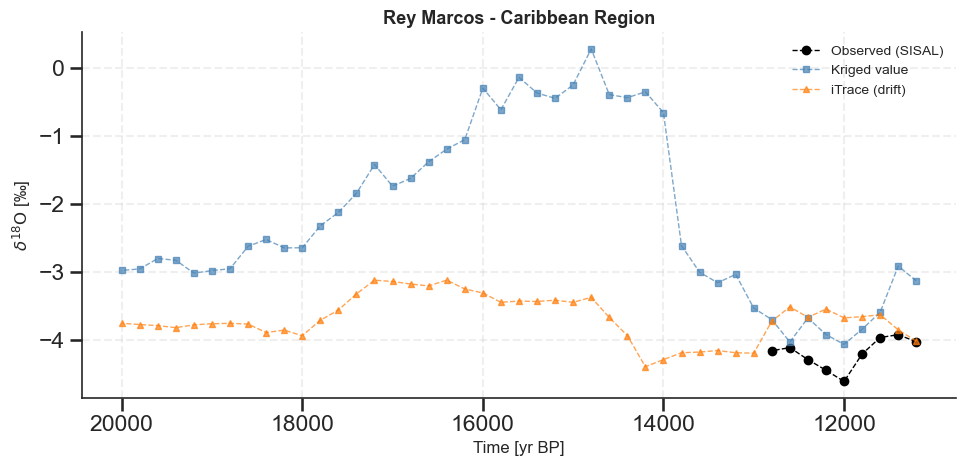

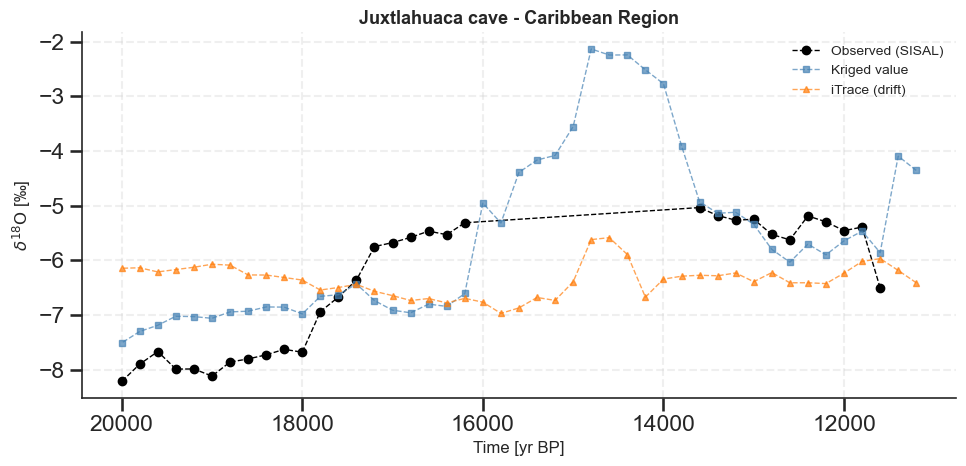

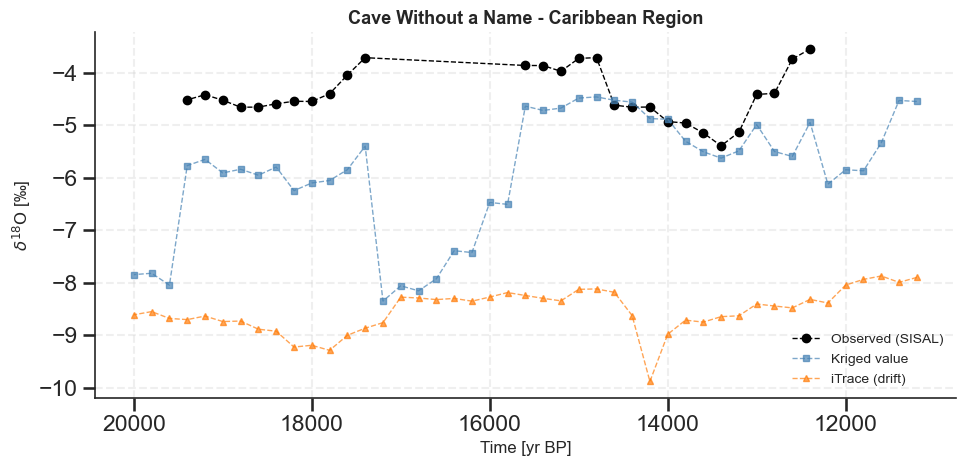

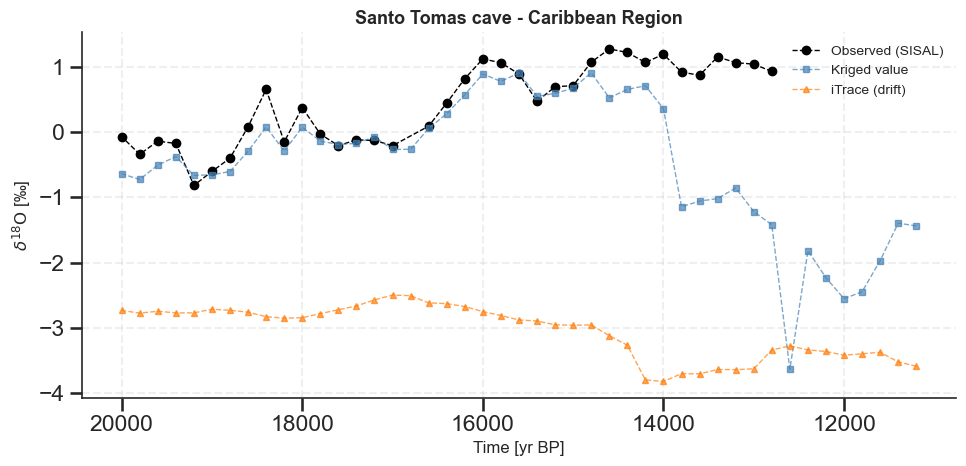

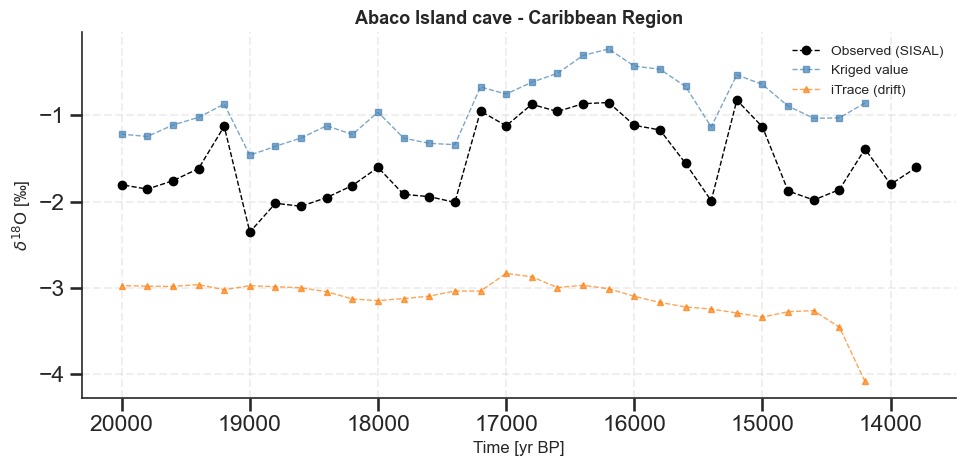

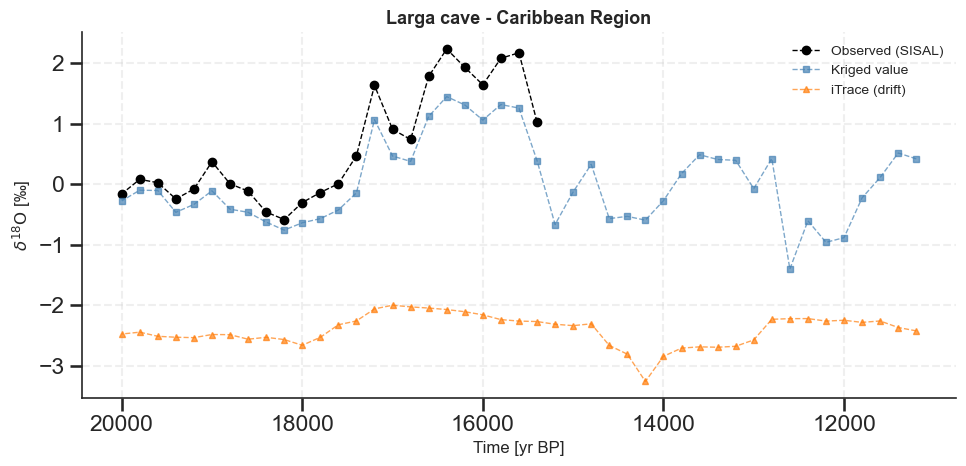

In [46]:
# Filter caves in the Caribbean region
caribbean_caves = crossval_df.loc[
    (crossval_df['lat'].between(12, 31)) & 
    (crossval_df['lon'].between(-100, -63)), 
    'site_name'
].unique()

# Plot time series for each Caribbean cave
for cave_name in caribbean_caves:
    # Get data for this cave
    cave_crossval = crossval_df[crossval_df['site_name'] == cave_name].sort_values('time')

    # Find closest gridpoint to this cave location
    cave_lat = cave_crossval['lat'].iloc[0]
    cave_lon = cave_crossval['lon'].iloc[0]
    
    # Calculate distances to all gridpoints in merged_df
    distances = np.sqrt(
        (merged_df['lat'] - cave_lat)**2 + 
        (merged_df['lon'] - cave_lon)**2
    )
    
    # Find closest gridpoint(s)
    closest_idx = distances.idxmin()
    
    # Get all time steps at the closest location
    drift_and_pred = merged_df[
        (merged_df['lat'] == merged_df.loc[closest_idx, 'lat']) & 
        (merged_df['lon'] == merged_df.loc[closest_idx, 'lon'])
    ].sort_values('time')

    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Plot observed values from crossval
    ax.plot(cave_crossval['time'], cave_crossval['z_obs'], '--o', 
            linewidth=1, markersize=6, label='Observed (SISAL)', color='black')
    
    # Plot kriged predictions
    ax.plot(drift_and_pred['time'], drift_and_pred['kriged_d18Op'], '--s', 
            linewidth=1, markersize=5, label='Kriged value', color='steelblue', alpha=0.7)
    
    # Plot iTrace values if available
    ax.plot(drift_and_pred['time'], drift_and_pred['itrace_d18Op'], '--^', 
            linewidth=1, markersize=5, label='iTrace (drift)', color='tab:orange', alpha=0.7)
    
    ax.set_xlabel('Time [yr BP]', fontsize=12)
    ax.set_ylabel(r'$\delta^{18}\text{O}$ [‰]', fontsize=12)
    ax.set_title(f'{cave_name} - Caribbean Region', fontsize=13, fontweight='bold')
    ax.invert_xaxis()
    ax.grid(alpha=0.3)
    ax.legend(frameon=False, fontsize=10)
    sns.despine()
    plt.tight_layout()
    plt.show()
